# Pipeline to

*   extract metadiscourse and style features for English Reddit posts and Chinese posts
*   Normalize metadiscourse features by post length
*   measure correlations between features










## Import packages

In [ ]:
%%capture
# old one - openai==1.55.3
!pip install openai==2.0.0 httpx==0.27.2 --force-reinstall --quiet

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import sys
from google.colab import drive
import re
import json
import numpy as np
import nltk

In [ ]:
import openai
from openai._client import OpenAI

In [ ]:
#to access openai api keys
!pip install --quiet python-dotenv

In [ ]:
## LLM API Calls - key
import dotenv

KEY_FILE_LOCATION = '/content/drive/MyDrive/API Keys/WWBP_OpenAIKey.env'
dotenv.load_dotenv(KEY_FILE_LOCATION)

True

In [ ]:
# always clear this output before moving to next cell.
#!echo $OPENAI_API_KEY

In [ ]:
openai.api_key = os.environ["OPENAI_API_KEY"]

## LLM Prompts to Label the Dataset In Terms of High- vs Low Context

In [ ]:
def label_contextLevel_english(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
    {
  "role": "system",
  "content": "You are a linguistics expert that annotates how high- versus low-context various two to three sentence-long utterances are. Answer this question: 'How much does this sentence rely on context (tone, situation, shared cultural knowledge) versus explicit wording to convey its meaning? 1 - Very low-context 2 - Low-context 3 - Moderate 4 - High-context 5 - Very high-context', unless otherwise stated. Return the output in float format."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate two to three sentence long utterances of various topics based on how high-context versus low-context they are.",
       "description": "For each utterance, answer this question: Answer this question: 'How much does this sentence rely on context (tone, situation, shared cultural knowledge) versus explicit wording to convey its meaning? 1 - Very low-context 2 - Low-context 3 - Moderate 4 - High-context 5 - Very high-context', unless otherwise stated. /
       ALWAYS FOLLOW THE RATING SCALE OF 1 (very low-context) TO 5 (very high-context). DO NOT EXPLAIN YOUR ANSWERS",
      }}
  }},
  "annotation_format": "Return the score as either 1, 2, 3, 4, or 5, in float format.",
  "example": {{
    "input": "Some guy tried to do the same thing with me once! He faked cancer for about a month, then one day, he “had a heart attack,” and told me the hospital he was admitted into. I called the hospital, and they had no record of him there. So I aggressively confronted the guy, he admitted he was lying about everything, and I told him he needed professional mental help. People who are THIS crazy are scary… they don’t know what’s right vs wrong.",
    "output": "1"
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

## LLM prompts to extract metadiscourse and style features

*   Metadiscourse features - Interactive and Interaction
*   There are two prompts below for metadiscourse features - one for English and one for Chinese.
* Style features for english



## English prompts

In [ ]:
## Run 2 - metadiscourse feature labeling.
def extract_metadiscourseFeatures_english(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
    {
  "role": "system",
  "content": "You are a linguistics expert that annotates metadiscourse markers in two to three sentence-long utterances. You return the annotated string in JSON format after, with the format as {'annotated_text' : the annotated output }."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate metadiscourse markers in two to three sentence-long utterances are.",
       "description": "Identify and label metadiscourse markers in the given text using angular brackets with the appropriate metadiscourse label. A word or symbol can be assigned more than one marker, in which case, all relevant markers should be enclosed in angular brackets sequentially. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>. DO NOT INCLUDE ANY MARKERS OUTSIDE OF THE ONES LISTED BELOW. IF THE MARKER HAS UNDERSCORES, LABEL THEM WITH UNDERSCORES, NOT DASHES, FOR EXAMPLE: IF YOU SEE A SELF-MENTION, LABEL AS word<self_mentions>. DO NOT EXPLAIN YOUR ANSWERS",
  "categories": {{
    "interactive": {{
      "": {{
        "definition": "Words that express semantic relation between main clauses.",
        "examples": ["additionally", "again", "also", "although", "as a result","at the same time", "because", "but", "consequently", "conversely", "even", "even though", "furthermore", "however", "in addition", "in the same way", "nonetheless", "on the other hand", "once", "rather", "regard", "result in", "since", "so", "still", "then", "therefore", "though", "too", "while", "yet"]
      }},
      "frame_markers": {{
        "definition": "Words that refer to discourse acts, sequences, or text stages.",
        "examples": ["to begin with", "my point is", "add", "at this point", "at this stage", "back", "begin", "finally", "first", "first of all", "goal", "in regard to", "in short", "last", "next", "my advice is", "now", "purpose", "return to", "second", "subsequently", "third", "want to", "well", "would like to"]
      }},
      "endophoric_markers": {{
        "definition": "Words that refer to information from other parts of the text.",
        "examples": ["what I mentioned before", "the above", "above", "below", "first"]
      }},
      "evidentials": {{
        "definition": "Words that refer to a source of information from other texts.",
        "examples": ["as xxx once said", "according to xxx"]
      }},
      "code_glosses": {{
        "definition": "Words that help readers grasp meanings of ideational material.",
        "examples": ["such as", "for example", "that is", "I mean", "in fact", "in other words", "indeed", "say", "this means", "which means"]
      }}
    }},
    "interactional": {{
      "hedges": {{
        "definition": "Words that withhold the writer's full commitment to a proposition.",
        "examples": ["might", "could", "I'm not sure but", "likely", "a little", "about", "almost", "apparent", "apparently", "appear", "around", "assume", "believe", "certain", "claim", "could", "doubt", "fairly", "feel", "felt", "generally", "guess", "I think", "in general", "in most cases", "in my opinion", "in my view", "know", "largely", "likely", "may", "maybe", "might", "mostly", "often", "perhaps", "possible", "possibly", "presumably", "probably", "quite", "rather", "relatively", "seems", "should", "sometimes", "somewhat", "suspect", "tend to", "typically", "unlikely", "usually", "would"]
      }},
      "boosters": {{
        "definition": "Words that emphasize force or the writer's certainty in a proposition.",
        "examples": ["definitely", "certainly", "really", "in fact", "exclamation marks (!)", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"]
      }},
      "attitude_markers": {{
        "definition": "Words that express the writer's attitude to a proposition.",
        "examples": ["I agree", "unexpectedly", "agree", "amazing", "appropriate", "disappointed", "disappointing", "even", "expected", "fortunate", "fortunately", "hopeful", "hopefully", "important", "importantly", "inappropriate", "interesting", "interestingly", "prefer", "see", "surprisingly", "understandable", "understandably", "unexpected", "unfortunate", "unfortunately", "unusual", "usual"]
      }},
      "engagement_markers": {{
        "definition": "Words that explicitly refer to or build a relationship with the reader.",
        "examples": ["consider this", "you can see that", "have to", "question marks (?)", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our", "really", "recall", "remember", "see", "should", "think about", "think of", "us", "use", "we", "you", "your"]
      }},
      "self_mentions": {{
        "definition": "Words that indicate explicit reference to the author(s).",
        "examples": ["I", "we", "our", "me", "us", "my"]
      }}
    }},
    "other": {{
      "deontic_modal_words": {{
        "definition": "Words or word phrases that express concepts of obligation, permission, and prohibition, often in the context of what a person or agent is required, allowed, or forbidden to do.",
        "examples": ["should", "must", "ought to", "may", "can", "must not", "cannot", "have to", "I suggest", "got to"]
      }},
      "adverbs_of_degree": {{
        "definition": "Words that indicate the intensity, extent, or level of an action, adjective, or another adverb",
        "examples": ["very", "extremely", "highly", "incredibly", "positively", "quite", "fairly", "somewhat", "rather", "pretty", "barely", "slightly", "almost", "enough", "so", "completely", "too"]
      }},
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "slang_and_colloquialisms": {{
        "definition": "Words or phrases commonly used in natural, highly informal, spoken conversations rather than in formal or literary writing, including ones popular in specific social groups.",
        "examples": ["going postal", "bogus", "adulting", "y'all", "what's up", "dope", "sus", "fixing to", "bruh", "feeling blue", "yeet", "bussin". "glow up", "slay", "wicked", "old fogey", "rizz", "gonna", "wanna", "brainrot", "clout", "cooked", "crash out", "delulu", "drip", "extra", "flex", "girl math", "glow-up", "GOAT", "let them cook", "irl", "mood"]
      }},
      "positive_connotations": {{
        "definition": "Words with emotional or cultural associations that goes beyond their literal meanings, with positive connotations evoke pleasant or favorable feelings and associations.",
        "examples": ["ambitious", "brave", "caring", "determined", "dazzling", "empowering", "eager", "flourishing", "generous", "meticulous", "spirited", "hopeful", "inquisitive", "heroic", "calm", "friendly", "quintessential", "vibrant", "youthful", "faithful", "eloquent"]
      }},
      "negative_connotations": {{
        "definition": "Words with unpleasant or unfavorable emotional associations or implied meanings, beyond their literal definitiona.",
        "examples": ["abrasive", "bleak", "clumsy", "dismal", "evasive", "frivolous", "gruesome", "harsh", "ignorant", "jaded", "knotty", "lethargic", "malicious", "nefarious", "obnoxious", "pernicious", "querelous", "repugnant", "sinister", "toxic", "unsettling", "vile", "warped", "xenophobic"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }},
      "place_time_svo": {{
        "definition": "Phrases that contain the setting, specifically the time and/or place, before the main subject-verb-object phrase of the text.",
        "examples": ["In New York, at noon, I ate a sandwich", "It was the dead of night in the woods when they came outside", "In the playground at noon there's going to be a fight", "Seven years ago, on my birthday, my mother gave me cake", "In Fallujah, Iraq, the U.S. Marines fought the Iraqi army", "In a land, far, far, away, there was a princess with fair hair", "Yesterday, my mother called me", "In Japan, during August, there is a festival called Tanabata"]
      }},
      "chronological_markers": {{
        "definition": "Words or phrases that establish a chronological ordering of events within the text."
        "examples": ["first", "next", "second", "afterwards", "later", "finally", "then", "before", "during", "after", "today", "tomorrow"]
      }},
      "causal_markers": {{
        "definition": "Words or phrases that establish a cause-and-effect relationship between events within the text."
        "examples": ["since", "because", "thus", "so", "as", "therefore", "due to", "as a result"]
      }}
    }}
  }},
  "annotation_format": "Enclose identified metadiscourse markers in angular brackets following the word. If a word has multiple markers, all relevant labels should be included sequentially within the brackets. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>.",
  "example": {{
    "input": "Some guy tried to do the same thing with me once! He faked cancer for about a month, then one day, he “had a heart attack,” and told me the hospital he was admitted into. I called the hospital, and they had no record of him there. So I aggressively confronted the guy, he admitted he was lying about everything, and I told him he needed professional mental help. People who are THIS crazy are scary… they don’t know what’s right vs wrong.",
    "output": "Some guy tried to do the same thing with me<self-mentions> once!<boosters> He faked cancer for about a month, then<transitions> one day, he “had a heart attack,”<boosters> and told me<self-mentions> the hospital he was admitted into. I<self-mentions> called the hospital, and they had no record of him there. So I<self-mentions> aggressively confronted the guy, he admitted he was lying about everything, and I<self-mentions> told him he needed professional mental help. People who are THIS<boosters> crazy are scary… they don’t know what’s right vs wrong."
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  # gpt-5 only params: reasoning_effort
  # reasoning_effort="low",
  verbosity="low",
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0,
  response_format={"type": "json_object"}
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

In [ ]:
## Run 2 - style feature analysis
def extract_styleFeatures_english(post, temp):
    response = openai.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {
                "role": "system",
                "content": "You are an AI assistant trained to evaluate and annotate utterances in social media posts based on various criteria. Rate each question on a scale from 1 (not at all) to 7 (very much), unless otherwise stated. Return the output in JSON format"
            },
            {
                "role": "user",
                "content": f'''
                {{
                    "task": "Annotate social media post utterances (defined as: 2-3 sentence long segments) based on multiple linguistic and psychological dimensions.",
                    "description": "Rate each of the following questions on a scale of 1 (not at all) to 7 (very much). Select temporal orientation as past, present, or future. If multiple orientations apply, return all that apply.\
                    ALWAYS FOLLOW THE RATING SCALE OF 1 (not at all) TO 7 (very much) EXCEPT FOR TEMPORAL ORIENTATION. GIVE A RATING FOR EVERY DIMENSION LISTED BELOW, AND ONLY THOSE. DO NOT EXPLAIN YOUR ANSWERS.\
                    ",
                    "criteria": {{
                        "informativeness": "How much does this utterance provide information or solutions?",
                        "constructive_feedback": "How much does this utterance offer constructive feedback?",
                        "author_revelation": "How much does this utterance reveal about the author?",
                        "comprehensibility": "How easy is this utterance to understand?",
                        "detail_level": "How detailed is this utterance?",
                        "explicitness": "How explicit is this utterance?",
                        "context_dependence": "How much additional context is needed to understand this utterance?",
                        "persuasiveness": "How much does this utterance attempt to persuade the reader of a point?",
                        "logical_reasoning": "How much does this utterance emphasize logical reasoning?",
                        "anecdotal_reasoning": "How much does this utterance rely on anecdotal or experiential reasoning?",
                        "right_wrong": "How much does this utterance frame actions in terms of right and wrong?",
                        "tradition": "How much does this utterance appeal to tradition or authority?",
                        "supportiveness": "How supportive is this utterance?",
                        "empathy": "How empathetic is this utterance?",
                        "status_suggestion": "How much does this utterance suggest that the people are of different status?",
                        "status_appropriateness": "How appropriate is the utterance for their status difference?",
                        "personal_choice": "How much does this utterance emphasize personal choice?",
                        "group_harmony": "How much does this utterance emphasize group harmony?",
                        "shared_responsibility": "How much does this utterance emphasize shared responsibility?",
                        "self-reliance": "How much does this utterance emphasize self-reliance?",
                        "group_wellbeing": "How much does this utterance focus on group well-being?",
                        "self_growth": "How much does this utterance emphasize self-growth?",
                        "self_responsibility": "How much does this utterance place responsibility on the individual?",
                        "ext_responsibility": "How much does this utterance place responsibility on external factors or others?",
                        "other_reliance": "How much does this utterance emphasize relying on others?",
                        "accomplish_tasks": "How much does this utterance prioritize accomplishing tasks?",
                        "implied_meaning": "How much does this utterance imply meaning rather than state it?",
                        "creative_text": "How much does this utterance use metaphors, analogies, or storytelling to convey its message?",
                        "repetitive": "How much does this utterance repeat key ideas or phrases to enhance clarity?",
                        "point_faults": "How much does this utterance avoid naming problems or pointing out faults directly?",
                        "tactful": "How tactful is this utterance?",
                        "critique": "How much does this utterance soften critique through indirect or roundabout language?",
                        "challenge": "How openly does this utterance challenge assumptions, behaviors, or norms?",
                        "conflict": "How much does this utterance downplay disagreement or conflict to maintain social harmony?",
                        "build_connection": "How much does this utterance include personal anecdotes or experiences to build connection?",
                        "orientation": "Which time period does this utterance most focus on?",
                        "vividness": "How vivid is this utterance?",
                        "expressfulness": "How expressful is this utterance?",
                        "vagueness": "How vague is this utterance?",
                        "matter_of_factness": "How matter-of-fact is this utterance?",
                        "abstractness": "How abstract is this utterance?",
                        "figurativeness": "How figurative is this utterance?",
                        "concreteness": "How concrete is this utterance?",
                        "formality": "How formal is this utterance?",
                        "conciseness": "How concise is this utterance?",
                        "verbosity": "How verbose is this utterance?",
                        "emotionality": "How emotional is this utterance?",
                        "impersonality": "How impersonal is this utterance?",
                        "politeness": "How polite is this utterance?",
                        "directness": "How direct is this utterance?",
                        "bluntness": "How blunt is this utterance?",
                        "cultural-relatedness": "How much cultural knowledge does this utterance use?",
                        "exposition": "How expository is this utterance?",
                        "narrative": "How narrative is this utterance?",
                        "narrative_mode": "How much does this utterance use a narrative mode of discourse?",
                        "expository_mode": "How much does this utterance use an expository mode of discourse?",
                        "storytelling": "How much does this utterance tell a story?",
                        "indirect": "How indirect is this utterance?",
                        "suspensefulness": "How suspenseful is this utterance?",
                        "prosociality": "How prosocial is this utterance?",
                        "clarity": "How much does this utterance focus on clarity?",
                        "engagement": "How engaging is this utterance?",
                        "showing": "How much does this utterance focus on showing rather than telling?",
                        "context-first": "How much does this utterance focus on context over information?",
                        "setting-first": "How much does this utterance show the setting (place and time) before the main information?",
                        "chronological": "How much does this utterance use chronological/temporal transitions between words?",
                        "transition_level": "How much does this utterance use transition words between parts of itself?",
                        "causal_level": "How much does this utterance use cause and effect words to connect parts of itself?"
                    }},
                    "rating_scale": "For all questions (except temporal orientation), rate on a scale of 1 (not at all) to 7(very much or a lot)."
                }},
                "text": "{post}"
               }}
                '''
            }
        ],
        # temperature=temp,
        # max_tokens=1024,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
        response_format={"type": "json_object"}
    )

    output = response.choices[0].message.content.strip()
    return output

## Chinese prompts

In [ ]:
def extract_metadiscourseFeatures_chinese(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
     {
  "role": "system",
  "content": "You are a linguistics expert that annotates metadiscourse markers in social media posts."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate metadiscourse markers in chinese social media posts.",
       "description": "Identify and label metadiscourse markers in the given chinese text using angular brackets with the appropriate metadiscourse label. A word or symbol can be assigned more than one marker, in which case, all relevant markers should be enclosed in angular brackets sequentially. USE ENGLISH NAMES WHEN LABELLING MARKERS.",
  "
  "categories": {{
    "interactive": {{
      "transitions": {{
        "definition": "互动型元话语标记是帮助引导读者理解文本的词语。",
        "examples": ["一方面 … 另一方面", "此外", "除 … 之外", "另外", "进一步","并且", "而且", "不仅 … 而且(更, 还)", "既不 … 也不 …", "不论 … 还 …", "既 … 也 …", "也", "虽然(尽管) … 但是 …", "不是 … 而是 …", "并非 … 而是 …", "不过", "反之", "否则", "然而", "相反", "可是", "而", "之所以 … 是因为 …", "因为 … 所以 …", "因此", "由于", "鉴于", "只有 … 才 …"]
      }},
      "frame_markers": {{
        "definition": "框架标记语是指代话语行为、序列或文本阶段的词语。",
        "examples": ["第一 …, 第二 … .", "一 …, 二 …", "(A) …, (B) …", "① …, ② …", "首先, 其次 (接着, 再则)", "先 … 再 …", "综上所述", "总而言之", "总体来说", "总之", "从 … 的角度(视角)来看", "对 … 而言(来说)", "就 … 来讲", "从 … 讲", "在 … 的前提下", "在 … 领域(方面)", "在 … 情况下(过程中)", "当 … 时", "到目前为止", "迄今为止", "目前", "至此", "近年来", "… 年代以来", "最近", "近来", "与此同时", "同时"]
      }},
      "endophoric_markers/ 内指标记语": {{
        "definition": "内指标记语是指代文本其他部分信息的词语。",
        "examples": ["下面", "以下", "上述", "在下一节里", "以上所述"]
      }},
      "evidentials": {{
        "definition": "引证标记语是指代其他文本信息来源的词语。",
        "examples": ["据此", "根据", "按照", "由 … 看出", "… 指出", "… 表明", "由此看来", "… 论述道", "从 … 可见", "… 的研究显示"]
      }},
      "code_glosses": {{
        "definition": "解释标记语是帮助读者理解概念内容意义的词语。",
        "examples": ["定义为", "即", "… 是 …", "… 指 …", "或者(说)", "相当于", "意味着", "那就是", "意思是说", "同样", "换言之", "也可以说", "换句话说", "这就是说", "例句 …", "例如", "比如", "正如", "诸如", "譬如", "更具体地说"]
      }}
    }},
    "interactional": {{
      "hedges": {{
        "definition": "模糊限制语是减弱作者对命题的完全承诺的词语。",
        "examples": ["可能会", "也许", "很有可能的是", "似乎", "在很大 (某种, 一定)程度上", "尝试", "试图", "如果 … 就 …", "一般情况下", "一般而言", "一般", "往往", "几乎", "大致", "基本上", "恐怕", "认为"]
      }},
      "boosters": {{
        "definition": "强势语是强调命题力量或作者确定性的词语。",
        "examples": ["实际上", "事实上", "其实", "确实", "的确", "尤其(特别)是", "正是", "甚至", "当然", "着重强调", "需要指出的是", "值得一提的是", "严格来说", "很明显", "显然", "明确地", "必须", "应该"]
      }},
      "attitude_markers/ 态度标记语": {{
        "definition": "态度标记语是表达作者对命题态度的词语。",
        "examples": ["遗憾的是", "必然", "一定会", "从根本上讲", "实事求是地说", "重要的是"]
      }},
      "engagement_markers/ 介入标记语": {{
        "definition": "介入标记语是明确指代或与读者建立关系的词语。",
        "examples": ["我们", "请看", "再看", "见后", "下面分而述之(详细探讨)", "先看下面的例句", "必须", "应该"]
      }},
      "self_mentions": {{
        "definition": "自指语是加强与读者互动或建立关系的词语。",
        "examples": ["我们", "笔者", "本文作者"]
      }}
    }}
  }},
  "annotation_format": "Enclose identified metadiscourse markers in angular brackets following the word. If a word has multiple markers, all relevant labels should be included sequentially within the brackets.。",
  "example": {{
    "input": "有个人曾经试图对我做过同样的事情！他假装自己得了癌症大约一个月，然后有一天，他“心脏病发作”了，并告诉我他住进了一家医院。我打电话给医院，他们那里根本没有他的记录。所以我强烈地质问了他，他承认他在撒谎，我告诉他他需要专业的心理帮助。像这样疯狂的人很可怕……他们分不清是非对错。",
    "output":"有个人曾经试图对我<self_mentions>做过同样的事情<boosters>！他假装自己得了癌症大约一个月，然后<transitions>有一天，他“心脏病发作”了<boosters>，并告诉我<self_mentions>他住进了一家医院。我<self_mentions>打电话给医院，他们那里根本没有他的记录。\
    所以我<self_mentions>强烈地质问了他，他承认他在撒谎，我<self_mentions>告诉他他需要专业的心理帮助。像这样<boosters>疯狂的人很可怕……他们分不清是非对错。"
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

# All Languages' Utterance Length/Sentence Count Information

In [ ]:
# Getting each language's labeled context input's average words per utterance
# and their sentence per utterance counts

from nltk.tokenize import word_tokenize

english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/labeled_subtitles_context_input.csv')
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/translated_chinese_subtitles_input.csv')


english_labeled_context_input_df['utterance'] = english_labeled_context_input_df['utterance'].astype(str)
chinese_labeled_context_input_df['translated_text'] = chinese_labeled_context_input_df['translated_text'].astype(str)

english_avg_words_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(x.split())).mean()
print("english - avg words per utterance: ", english_avg_words_per_utterance)
english_avg_sentences_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("english - avg sentences per utterance: ", english_avg_sentences_per_utterance)
chinese_avg_words_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("chinese - avg words per utterance: ", chinese_avg_words_per_utterance)
chinese_avg_sentences_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("chinese - avg sentences per utterance: ", chinese_avg_sentences_per_utterance)


english - avg words per utterance:  10.322
english - avg sentences per utterance:  1.973
chinese - avg words per utterance:  9.507
chinese - avg sentences per utterance:  2.105


In [ ]:
# Getting each language's labeled context input's average words per utterance
# and their sentence per utterance counts

from nltk.tokenize import word_tokenize

english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/labeled_spoken_context_input.csv')
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/translated_chinese_spoken_input.csv')


english_labeled_context_input_df['utterance'] = english_labeled_context_input_df['utterance'].astype(str)
chinese_labeled_context_input_df['translated_text'] = chinese_labeled_context_input_df['translated_text'].astype(str)

english_avg_words_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(x.split())).mean()
print("english - avg words per utterance: ", english_avg_words_per_utterance)
english_avg_sentences_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("english - avg sentences per utterance: ", english_avg_sentences_per_utterance)
chinese_avg_words_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("chinese - avg words per utterance: ", chinese_avg_words_per_utterance)
chinese_avg_sentences_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("chinese - avg sentences per utterance: ", chinese_avg_sentences_per_utterance)


english - avg words per utterance:  12.435
english - avg sentences per utterance:  1.796
chinese - avg words per utterance:  12.433
chinese - avg sentences per utterance:  2.023


In [ ]:
# Getting each language's labeled context input's average words per utterance
# and their sentence per utterance counts

from nltk.tokenize import word_tokenize

english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/labeled_testing_context_input.csv')
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/translated_chinese_testing_input.csv')


english_labeled_context_input_df['utterance'] = english_labeled_context_input_df['utterance'].astype(str)
chinese_labeled_context_input_df['translated_text'] = chinese_labeled_context_input_df['translated_text'].astype(str)

english_avg_words_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(x.split())).mean()
print("english - avg words per utterance: ", english_avg_words_per_utterance)
english_avg_sentences_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("english - avg sentences per utterance: ", english_avg_sentences_per_utterance)
chinese_avg_words_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("chinese - avg words per utterance: ", chinese_avg_words_per_utterance)
chinese_avg_sentences_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("chinese - avg sentences per utterance: ", chinese_avg_sentences_per_utterance)


english - avg words per utterance:  18.399
english - avg sentences per utterance:  2.04
chinese - avg words per utterance:  19.668
chinese - avg sentences per utterance:  2.165


In [ ]:
# Getting each language's labeled context input's average words per utterance
# and their sentence per utterance counts

from nltk.tokenize import word_tokenize

english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/labeled_context_input.csv')
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/translated_chinese_input.csv')


english_labeled_context_input_df['utterance'] = english_labeled_context_input_df['utterance'].astype(str)
chinese_labeled_context_input_df['translated_text'] = chinese_labeled_context_input_df['translated_text'].astype(str)

english_avg_words_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(x.split())).mean()
print("english - avg words per utterance: ", english_avg_words_per_utterance)
english_avg_sentences_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("english - avg sentences per utterance: ", english_avg_sentences_per_utterance)
chinese_avg_words_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("chinese - avg words per utterance: ", chinese_avg_words_per_utterance)
chinese_avg_sentences_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("chinese - avg sentences per utterance: ", chinese_avg_sentences_per_utterance)


english - avg words per utterance:  45.192
english - avg sentences per utterance:  3.976
chinese - avg words per utterance:  44.61
chinese - avg sentences per utterance:  3.844


In [ ]:
# Getting each language's labeled context input's average words per utterance
# and their sentence per utterance counts

from nltk.tokenize import word_tokenize

english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/labeled_news_context_input.csv')
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/translated_chinese_news_input.csv')


english_labeled_context_input_df['utterance'] = english_labeled_context_input_df['utterance'].astype(str)
chinese_labeled_context_input_df['translated_text'] = chinese_labeled_context_input_df['translated_text'].astype(str)

english_avg_words_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(x.split())).mean()
print("english - avg words per utterance: ", english_avg_words_per_utterance)
english_avg_sentences_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("english - avg sentences per utterance: ", english_avg_sentences_per_utterance)
chinese_avg_words_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("chinese - avg words per utterance: ", chinese_avg_words_per_utterance)
chinese_avg_sentences_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("chinese - avg sentences per utterance: ", chinese_avg_sentences_per_utterance)


english - avg words per utterance:  24.546
english - avg sentences per utterance:  2.357
chinese - avg words per utterance:  25.715
chinese - avg sentences per utterance:  2.412


# Joint Dataset Analysis

## Joint Labeled Utterance Table

In [8]:
havaldar_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/labeled_context_input.csv')
testing_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/labeled_testing_context_input.csv')
subtitles_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/labeled_subtitles_context_input.csv')
spoken_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/labeled_spoken_context_input.csv')
news_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/labeled_news_context_input.csv')

joint_utterance_df = pd.concat([havaldar_utterance_df, testing_utterance_df, subtitles_utterance_df, spoken_utterance_df, news_utterance_df])
joint_utterance_df

,Unnamed: 0,utterance_id,utterance,labeled_utterance,avg_labeled_utterance
0,0,u4326,"In fact, the United States Military requires a...",1.0,1.0
1,1,u2436,It's circular logic to say that it's clearly a...,4.0,4.0
2,2,u3975,The sentence reads Directors as diverse as Jim...,4.0,4.0
3,3,u3037,"As a measure against Wikipedia: Recentism, I'd...",2.0,2.0
4,4,u743,"Barry, you are absolutely right. I brought thi...",3.0,3.0
...,...,...,...,...,...
995,995,u243689,Malibu's trunk suffers from the GM - typical s...,2.0,2.0
996,996,u1973,Vu Quang Hien from Vietnam wants to know more ...,1.0,1.0
997,997,u42160,Musume official said the painting may be artis...,2.0,2.0
998,998,u115650,"Instead, he devoted an entire book to it, Emil...",4.0,4.0


In [9]:
chinese_havaldar_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/labeled_chinese_context_input.csv')
chinese_testing_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/labeled_chinese_testing_context_input.csv')
chinese_subtitles_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/labeled_chinese_subtitles_context_input.csv')
chinese_spoken_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/labeled_chinese_spoken_context_input.csv')
chinese_news_utterance_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/labeled_chinese_news_context_input.csv')

chinese_joint_utterance_df = pd.concat([chinese_havaldar_utterance_df, chinese_testing_utterance_df, chinese_subtitles_utterance_df, chinese_spoken_utterance_df, chinese_news_utterance_df])
chinese_joint_utterance_df

,Unnamed: 0,utterance_id,utterance,labeled_utterance,avg_labeled_utterance
0,0,u4326,虽然以前很多情况下与英文Philip类似的国王都翻译成腓力，但毕竟是以英文为中心的旧式做法。...,1.0,1.0
1,1,u2436,犯錯不是問題，知錯能改就好。 不知錯，那也無話可說。 就是這麼簡單。,1.0,1.0
2,2,u3975,文中关于农保的表述有明显贬低。 “此外，2009年7月，温家宝表示要建立农村养老保障制度，最...,1.0,1.0
3,3,u3037,真的不好意思，蘋果日報與衛報的新聞在他們的官方網站中只會放置一段短時間，蘋果日報的早已沒有了...,2.0,2.0
4,4,u743,敝人不太明白閣下的意思。 1951年5月4日這段，依敝人的理解，其用意是藉由「麥克阿瑟簽署了...,2.0,2.0
...,...,...,...,...,...
995,995,u243689,马里布的主干受到了通用典型的小型开放，但它用了漂亮的柜台盖子班轮干线和抓斗处理，所以你不必淤...,5.0,5.0
996,996,u1973,来自越南的Vu Quang Hien想了解更多关于乙肝的知识。肝炎是攻击肝脏的一系列病毒感染...,1.0,1.0
997,997,u42160,博物馆官员称这幅画在艺术上很大胆，但应对其进行谴责。,2.0,2.0
998,998,u115650,而他就这一点写出了《艾米莉•博斯特的网络礼仪》这本书。,4.0,4.0


## Joint Metadiscourse Table

In [10]:
havaldar_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/output_metadiscourseFeatures.csv')
testing_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/output_testing_metadiscourseFeatures.csv')
subtitles_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/output_subtitles_metadiscourseFeatures.csv')
spoken_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/output_spoken_metadiscourseFeatures.csv')
news_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/output_news_metadiscourseFeatures.csv')

joint_metadiscourse_df = pd.concat([havaldar_metadiscourse_df, testing_metadiscourse_df, subtitles_metadiscourse_df, spoken_metadiscourse_df, news_metadiscourse_df])
joint_metadiscourse_df

,Unnamed: 0,utterance_id,utterance,avg_labeled_utterance,labeled_utterance,engagement_markers,hedges,attitude_markers,frame_markers,boosters,...,positive_connotations,emotional_self_disclosures,slang_and_colloquialisms,figurative_language,negative_connotations,pleonasms,hedges_deontic_modal_words,idioms,hedges_adverbs_of_degree,transitions_chronological_markers
0,0,u1984,"Spelunky (2008) by Derek Yu, The Binding of Is...",2.0,"Spelunky (2008) by Derek Yu, The Binding of Is...",0.002825,0.002825,0.002825,0.002825,0.002825,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,1,u721,this has been the most positive interaction I ...,3.0,this has been the most positive interaction I<...,0.000000,0.005780,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,2,u2503,"This statement has been added, removed and had...",2.0,This<explicit_references> statement has been a...,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,3,u2963,"in the English language, is this movement bett...",2.0,"in the English language<place_time_svo>, is th...",0.003663,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,4,u1411,There are cases when more information does not...,3.0,There are cases when more information does not...,0.000000,0.000000,0.000000,0.000000,0.005405,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,u398483,"""Remember, Eliza, that he does not know Jane's...",2.0,"Remember<engagement_markers>, Eliza<explicit_r...",0.028571,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN
996,996,u296815,"This, then, is the unique source of our streng...",4.0,"This<endophoric_markers>, then<transitions>, i...",0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN
997,997,u59255,But the sector enjoys subsidies from the state...,1.0,But<transitions> the sector enjoys subsidies f...,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN
998,998,u444000,"So far, shoppers are winning the price game ab...",1.0,"So<transitions> far, shoppers are winning the ...",0.000000,0.012048,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN


In [11]:
chinese_havaldar_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/chinese_output_metadiscourseFeatures.csv')
chinese_testing_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/chinese_output_testing_metadiscourseFeatures.csv')
chinese_subtitles_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/chinese_output_subtitles_metadiscourseFeatures.csv')
chinese_spoken_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/chinese_output_spoken_metadiscourseFeatures.csv')
chinese_news_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/chinese_output_news_metadiscourseFeatures.csv')

chinese_joint_metadiscourse_df = pd.concat([chinese_havaldar_metadiscourse_df, chinese_testing_metadiscourse_df, chinese_subtitles_metadiscourse_df, chinese_spoken_metadiscourse_df, chinese_news_metadiscourse_df])
chinese_joint_metadiscourse_df

,Unnamed: 0,utterance_id,utterance,avg_labeled_utterance,labeled_utterance,frame_markers,situation_dependent_references,chronological_markers,explicit_references,code_glosses,...,during,in_addition,even,you,in_advance,consider,even_though,as_long_as,can,in_the_same_way
0,0,u1984,介绍他如何提出了它，当时的人们如何反应，这件事如何影响了爱因斯坦的人生轨迹。 到“主要科學成...,3.0,介绍<frame_markers>他<situation_dependent_referen...,0.043956,0.032967,0.010989,0.010989,0.010989,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,u721,裁覆是說舉報內容非編輯破懷。 但如有人貼入侵權內容就是達舉報條件，不需3RR，只因侵權是很嚴...,4.0,裁覆是說舉報內容非編輯破懷。 但<transitions>如有人貼入侵權內容就是達舉報條件，...,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,u2503,會不會有人堅持(比如說該模板的一些編輯)認為台灣是中華人民共和國的一部分導致堅持要納入？ 現...,4.0,會不會有人堅持(比如說<code_glosses>該模板的一些編輯)認為台灣是中華人民共和國...,0.010309,0.000000,0.000000,0.000000,0.010309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,u2963,删除了这句:在他们的影响下，一些外国的朋友也跃跃欲试。。 因在新浪访问中，他们说过我们这个灵...,2.0,删除了这句:在他们的影响下，一些外国的朋友也<transitions>跃跃欲试。。 因<ca...,0.000000,0.000000,0.000000,0.000000,0.011111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,u1411,抱歉回复晚了，首先谢谢你的意见。 不过我们在这里讨论，不用于编辑。 可以有各有各的色彩，少拿...,2.0,抱歉回复晚了，首先<frame_markers>谢谢你的<engagement_marker...,0.014286,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,u398483,“伊丽莎，你得记住，他可不象你那么懂得吉英的性格。”,4.0,“伊丽莎<explicit_references>，你<engagement_markers...,0.000000,0.000000,0.000000,0.076923,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
996,996,u296815,那么这就是做为一个卫生机构我们独特的力量来源。,3.0,那么<transitions>这就是做为<causal_markers>一个卫生机构我们<s...,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,997,u59255,然而，金融业通过利用央行的最后贷款人职能、以及显性和隐性的免于破产的担保，享受着政府的补贴。,1.0,然而<transitions>，金融业通过利用央行的最后贷款人职能、以及<transitio...,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998,998,u444000,根据电商比价网站Decide.com提供的数据，迄今为止，买家在价格游戏中输赢参半──大约一...,1.0,根据<evidentials>电商比价网站Decide.com提供的数据，迄今为止，买家在价...,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Joint Style Table

In [12]:
havaldar_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/output_styleFeatures.csv')
testing_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/output_testing_styleFeatures.csv')
subtitles_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/output_subtitles_styleFeatures.csv')
spoken_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/output_spoken_styleFeatures.csv')
news_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/output_news_styleFeatures.csv')

joint_style_df = pd.concat([havaldar_style_df, testing_style_df, subtitles_style_df, spoken_style_df, news_style_df])
joint_style_df

,Unnamed: 0,message_id,informativeness,constructive_feedback,author_revelation,comprehensibility,detail_level,explicitness,context_dependence,persuasiveness,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
0,0,u1984,2,2,4,7,2,5,5,3,...,1,1,6,4,2,4,4,3,2,4
1,1,u721,2,3,4,7,2,3,6,2,...,1,4,6,3,2,4,3,4,4,2
2,2,u2503,5,3,2,6,4,5,5,3,...,1,2,6,3,2,4,4,4,4,2
3,3,u2963,5,4,3,6,4,6,3,4,...,1,2,6,3,2,3,1,1,2,2
4,4,u1411,4,5,5,6,2,5,6,4,...,1,2,6,4,3,4,1,2,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,u398483,4,5,4,6,2,5,6,4,...,1,3,6,2,2,2,1,1,1,1
996,996,u296815,2,1,3,6,2,4,7,4,...,1,4,5,2,1,5,1,1,3,1
997,997,u59255,6,1,2,6,5,6,4,3,...,1,1,6,2,1,3,1,1,1,4
998,998,u444000,6,1,2,7,5,6,2,2,...,1,2,7,3,1,2,1,2,2,1


In [13]:
chinese_havaldar_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/chinese_output_styleFeatures.csv')
chinese_testing_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/chinese_output_testing_styleFeatures.csv')
chinese_subtitles_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/chinese_output_subtitles_styleFeatures.csv')
chinese_spoken_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/chinese_output_spoken_styleFeatures.csv')
chinese_news_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/chinese_output_news_styleFeatures.csv')

chinese_joint_style_df = pd.concat([chinese_havaldar_style_df, chinese_testing_style_df, chinese_subtitles_style_df, chinese_spoken_style_df, chinese_news_style_df])
chinese_joint_style_df

,Unnamed: 0,message_id,informativeness,constructive_feedback,author_revelation,comprehensibility,detail_level,explicitness,context_dependence,persuasiveness,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
0,0,u1984,5,2,2,6,4,5,5,1,...,1,1,6,3,4,5,4,5,5,5
1,1,u721,6,3,2,6,3,6,5,3,...,1,2,6,2,1,3,3,1,1,4
2,2,u2503,4,5,4,6,4,4,6,4,...,1,4,5,3,2,5,3,1,2,4
3,3,u2963,6,2,4,6,5,6,5,3,...,1,2,6,3,2,4,4,3,4,5
4,4,u1411,4,3,4,7,2,5,5,3,...,1,4,7,4,2,4,4,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,u398483,3,4,4,7,2,5,6,4,...,1,3,6,3,2,2,1,1,1,1
996,996,u296815,2,1,3,6,2,3,6,3,...,1,4,5,2,1,4,2,1,2,3
997,997,u59255,5,1,4,6,5,6,2,4,...,1,1,6,4,2,2,1,1,2,5
998,998,u444000,6,1,1,7,4,6,2,2,...,1,1,7,3,2,3,3,2,2,3


# Joint Metadiscourse Information

In [ ]:
# Getting all languages' metadiscourse feature dataframes, means, and standard deviations

english_mean = joint_metadiscourse_df.loc[:, ~joint_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].mean()
english_std = joint_metadiscourse_df.loc[:, ~joint_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].std()
chinese_mean = chinese_joint_metadiscourse_df.loc[:, ~chinese_joint_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].mean()
chinese_std = chinese_joint_metadiscourse_df.loc[:, ~chinese_joint_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].std()

## All Languages' Style Feature Tables/Information

In [ ]:
# Getting all languages' style feature dataframes, means, and standard deviations

english_style_mean = joint_style_df.loc[:, ~joint_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].mean()
print("english style mean: ", english_style_mean)
english_style_std = joint_style_df.loc[:, ~joint_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].std()
chinese_style_mean = chinese_joint_style_df.loc[:, ~chinese_joint_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].mean()
print("chinese style mean: ", chinese_style_mean)
chinese_style_std = chinese_joint_style_df.loc[:, ~chinese_joint_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].std()

english style mean:  informativeness          3.2994
constructive_feedback    1.5146
author_revelation        2.5904
comprehensibility        6.2104
detail_level             2.4428
                          ...  
context-first            2.4706
setting-first            1.8616
chronological            1.6528
transition_level         1.8920
causal_level             2.2972
Length: 67, dtype: float64
chinese style mean:  informativeness          3.3576
constructive_feedback    1.5524
author_revelation        2.4916
comprehensibility        6.3542
detail_level             2.3386
                          ...  
context-first            2.3770
setting-first            1.9394
chronological            1.6946
transition_level         1.8610
causal_level             2.3572
Length: 67, dtype: float64


## English-Chinese Comparison

### Comparison of Meta-Discourse Feature Frequency

In [ ]:
# english_mean = english_mean[english_mean.index.isin(chinese_mean.index)]
pooled_std = np.sqrt( (((len(english_mean) - 1) * english_std + (len(chinese_mean) - 1) * chinese_std)) / (len(english_mean) + len(chinese_mean) - 2))
cohen_d = english_mean - chinese_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/english_chinese_joint_metadiscourse_cohen_d.xlsx')
print(cohen_d)

transitions                         -0.063241
self_mentions                       -0.061310
engagement_markers                  -0.051996
chronological_markers               -0.050895
deontic_modal_words                 -0.045733
adverbs_of_degree                   -0.044414
explicit_references                 -0.037422
boosters                            -0.036592
causal_markers                      -0.035824
hedges                              -0.035759
frame_markers                       -0.034141
place_time_svo                      -0.031889
attitude_markers                    -0.019390
situation_dependent_references      -0.018602
evidentials                         -0.018408
code_glosses                        -0.014865
endophoric_markers                  -0.011808
idioms                              -0.006956
negative_connotations               -0.005005
positive_connotations               -0.004134
figurative_language                 -0.004123
emotional_self_disclosures        

### Comparison of Style Feature Frequency

In [ ]:
english_style_mean = english_style_mean[english_style_mean.index.isin(chinese_style_mean.index)]

pooled_std = np.sqrt( (((len(english_style_mean) - 1) * english_style_std + (len(chinese_style_mean) - 1) * chinese_style_std)) / (len(english_style_mean) + len(chinese_style_mean) - 2))
cohen_d = english_style_mean - chinese_style_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/english_chinese_joint_style_cohen_d.xlsx')
print(cohen_d)

directness           -0.251632
explicitness         -0.248531
clarity              -0.223305
conciseness          -0.195445
matter_of_factness   -0.168531
                        ...   
showing               0.187128
engagement            0.192301
vagueness             0.258024
indirect              0.338028
implied_meaning       0.372462
Length: 67, dtype: float64


# Correlation analysis (English)

In [14]:
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from sklearn import metrics

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [15]:
joint_metadiscourse_df.drop(columns=['Unnamed: 0'], inplace=True)
joint_metadiscourse_df.rename(columns={'utterance_id': 'message_id'}, inplace=True)
joint_metadiscourse_df.head()

,message_id,utterance,avg_labeled_utterance,labeled_utterance,engagement_markers,hedges,attitude_markers,frame_markers,boosters,explicit_references,...,positive_connotations,emotional_self_disclosures,slang_and_colloquialisms,figurative_language,negative_connotations,pleonasms,hedges_deontic_modal_words,idioms,hedges_adverbs_of_degree,transitions_chronological_markers
0,u1984,"Spelunky (2008) by Derek Yu, The Binding of Is...",2.0,"Spelunky (2008) by Derek Yu, The Binding of Is...",0.002825,0.002825,0.002825,0.002825,0.002825,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,u721,this has been the most positive interaction I ...,3.0,this has been the most positive interaction I<...,0.000000,0.005780,0.000000,0.000000,0.000000,0.017341,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,u2503,"This statement has been added, removed and had...",2.0,This<explicit_references> statement has been a...,0.000000,0.000000,0.000000,0.000000,0.000000,0.007246,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,u2963,"in the English language, is this movement bett...",2.0,"in the English language<place_time_svo>, is th...",0.003663,0.000000,0.000000,0.000000,0.000000,0.010989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,u1411,There are cases when more information does not...,3.0,There are cases when more information does not...,0.000000,0.000000,0.000000,0.000000,0.005405,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [16]:
joint_style_df.drop(columns=['Unnamed: 0', 'orientation'], inplace=True)
joint_style_df.head()

,message_id,informativeness,constructive_feedback,author_revelation,comprehensibility,detail_level,explicitness,context_dependence,persuasiveness,logical_reasoning,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
0,u1984,2,2,4,7,2,5,5,3,3,...,1,1,6,4,2,4,4,3,2,4
1,u721,2,3,4,7,2,3,6,2,2,...,1,4,6,3,2,4,3,4,4,2
2,u2503,5,3,2,6,4,5,5,3,4,...,1,2,6,3,2,4,4,4,4,2
3,u2963,5,4,3,6,4,6,3,4,4,...,1,2,6,3,2,3,1,1,2,2
4,u1411,4,5,5,6,2,5,6,4,4,...,1,2,6,4,3,4,1,2,2,4


In [ ]:
metadiscourseStyleFeatures_df = pd.merge(joint_metadiscourse_df, joint_style_df, on='message_id', how='inner')

In [ ]:
print(len(metadiscourseStyleFeatures_df), len(joint_metadiscourse_df), len(joint_style_df))

5882 5000 5000


In [ ]:
print(metadiscourseStyleFeatures_df.dtypes)

message_id                object
utterance                 object
avg_labeled_utterance    float64
labeled_utterance         object
engagement_markers       float64
                          ...   
context-first              int64
setting-first              int64
chronological              int64
transition_level           int64
causal_level               int64
Length: 98, dtype: object


In [ ]:
## Computing correlations
X = metadiscourseStyleFeatures_df.select_dtypes(include=['int64', 'float64'])
X= X[X.columns[~X.columns.str.contains('nan')]]
corr = X.corr(method='pearson')

# source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(35, 35))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap='RdBu', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot=True,cbar_kws={"shrink": .5})
#sns.clustermap(X, z_score=1, metric='cosine')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
## hierarchical clustering
corr

,avg_labeled_utterance,engagement_markers,hedges,attitude_markers,frame_markers,boosters,explicit_references,transitions,self_mentions,causal_markers,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
avg_labeled_utterance,1.000000,0.143389,0.103615,0.032388,0.115497,0.115252,-0.002033,0.147177,0.112909,0.078263,...,0.185815,-0.065294,-0.486743,0.085477,0.053108,0.105876,-0.030048,-0.019539,-0.017668,-0.043708
engagement_markers,0.143389,1.000000,0.046443,-0.004407,0.041640,0.073007,-0.049327,0.006337,0.146653,-0.009911,...,0.039558,0.115124,-0.008584,0.189845,-0.055500,-0.111361,-0.112272,-0.087248,-0.117998,-0.081511
hedges,0.103615,0.046443,1.000000,-0.003506,0.027677,0.027523,-0.099214,0.037957,0.138166,-0.007970,...,0.023530,0.033329,-0.052693,0.041250,-0.012303,0.024013,-0.032916,-0.038661,-0.001544,0.010962
attitude_markers,0.032388,-0.004407,-0.003506,1.000000,-0.027748,0.014751,-0.028341,0.005936,0.025725,-0.017964,...,-0.002280,0.041674,-0.003436,0.044120,-0.015056,-0.001246,-0.038817,-0.025370,-0.002369,-0.018939
frame_markers,0.115497,0.041640,0.027677,-0.027748,1.000000,0.018835,-0.033683,-0.012796,0.106874,-0.012453,...,0.074306,0.004523,-0.060571,0.003429,-0.012089,0.019416,-0.003627,0.037666,0.032576,-0.063567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
context-first,0.105876,-0.111361,0.024013,-0.001246,0.019416,-0.026186,0.001338,-0.008968,-0.082044,0.044612,...,0.079429,0.038499,-0.088044,0.095399,0.178266,1.000000,0.683094,0.350719,0.446364,0.249285
setting-first,-0.030048,-0.112272,-0.032916,-0.038817,-0.003627,-0.051971,0.032972,-0.055684,-0.090579,-0.004745,...,0.091799,-0.027980,0.048878,0.084243,0.193825,0.683094,1.000000,0.434407,0.376175,0.131115
chronological,-0.019539,-0.087248,-0.038661,-0.025370,0.037666,-0.048512,-0.006448,0.010658,-0.029769,0.022658,...,0.175002,-0.059818,0.072034,0.102040,0.237661,0.350719,0.434407,1.000000,0.620030,0.198013
transition_level,-0.017668,-0.117998,-0.001544,-0.002369,0.032576,-0.032471,-0.053567,0.115343,-0.076260,0.079327,...,0.075029,0.076898,0.045431,0.158032,0.192805,0.446364,0.376175,0.620030,1.000000,0.426533


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
# drop columns that equal the list of names below
corr.drop(columns=['hedges_deontic_modal_words', 'hedges_adverbs_of_degree','transitions_chronological_markers'], inplace=True)

# drop rows where the 1st column equals the list of names from above
corr = corr[~corr.index.isin(['hedges_deontic_modal_words', 'hedges_adverbs_of_degree', 'transitions_chronological_markers'])]

corr.to_csv("/content/drive/MyDrive/High and Low Context Files/Results/joint_feature_correlation.csv")

In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
high_context_df = corr[['avg_labeled_utterance']]
high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)
high_context_df.to_excel("/content/drive/MyDrive/High and Low Context Files/Results/joint_context_correlation.xlsx")
print(high_context_df)

/tmp/ipython-input-2843658573.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)


                       avg_labeled_utterance
clarity                            -0.486743
explicitness                       -0.472845
matter_of_factness                 -0.416433
informativeness                    -0.376733
directness                         -0.354739
...                                      ...
indirect                            0.410375
implied_meaning                     0.451076
vagueness                           0.470670
context_dependence                  0.513992
avg_labeled_utterance               1.000000

[92 rows x 1 columns]


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
corr = pd.read_csv("/content/drive/MyDrive/High and Low Context Files/Results/joint_feature_correlation.csv", index_col = 0)

# Create a copy to modify
filtered_corr_matrix = corr.copy()

thresh = 0.65

corr_pairs = filtered_corr_matrix.abs().unstack().reset_index()
# or mask = coeff < thresh

# Rename columns for clarity
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs['Feature_1'] != corr_pairs['Feature_2']]

# To avoid duplicate pairs (A,B) and (B,A), sort features alphabetically and drop duplicates
corr_pairs['Ordered_Pair'] = corr_pairs.apply(lambda row: tuple(sorted([row['Feature_1'], row['Feature_2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset=['Ordered_Pair'])

# Get the correlation with context level for each feature
corr_pairs['Feature_1_Context_Corr'] = corr_pairs['Feature_1'].map(high_context_df['avg_labeled_utterance'])
corr_pairs['Feature_2_Context_Corr'] = corr_pairs['Feature_2'].map(high_context_df['avg_labeled_utterance'])

# Return the feature name that has the lower absolute value correlation with the context level
corr_pairs['Lower_Context_Feature'] = corr_pairs.apply(lambda row: row['Feature_1'] if abs(row['Feature_1_Context_Corr']) < abs(row['Feature_2_Context_Corr']) else
                                                       "Tie" if abs(row['Feature_1_Context_Corr']) == abs(row['Feature_2_Context_Corr']) else row['Feature_2'], axis=1)

# Sort by absolute correlation descending
most_corr_pairs = corr_pairs[corr_pairs['Correlation'] >= thresh]
most_corr_pairs = most_corr_pairs.sort_values(by='Correlation', ascending=False)
most_corr_pairs.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/joint_ordered_correlational_pairs.xlsx')


In [ ]:
# calculate Euclidean distance after taking absolute value
abs_dist = lambda u, v: np.sqrt(((np.abs(u)-np.abs(v))**2).sum())

sns.set(font_scale=1.5)
cg = sns.clustermap(corr, row_linkage=linkage(corr, metric=abs_dist), col_linkage=linkage(corr, metric=abs_dist), figsize=(40,40), cmap='RdBu', vmin=-1, vmax=1, center= 0, annot=True, cbar_kws={"shrink": .5})
cg.ax_row_dendrogram.set_visible(False)

Output hidden; open in https://colab.research.google.com to view.

## English - Correlation Clustering (Shapley Values)

In [17]:
english_labeled_context_input_df = joint_utterance_df
X = joint_style_df
X = X.drop(['message_id'], axis=1)

Y = english_labeled_context_input_df[['avg_labeled_utterance']]
Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 3 else 1)
print(Y)

0      0
1      1
2      1
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: avg_labeled_utterance, Length: 5000, dtype: int64


In [18]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=11)
X_pca = pca.fit_transform(X_norm)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

# note: first 11 components explain ~80.9% of total variance
# and follow Kaiser rule (>1 eigenvalue)

[9.52860206 7.68908859 6.27078233 5.17849677 4.17691349 2.71845785
 2.52102574 2.18711408 1.66761434 1.5764773  1.28795411]
[0.1421895  0.11473956 0.09357505 0.07727554 0.06232952 0.04056588
 0.03761972 0.03263697 0.02488479 0.02352481 0.01921935]


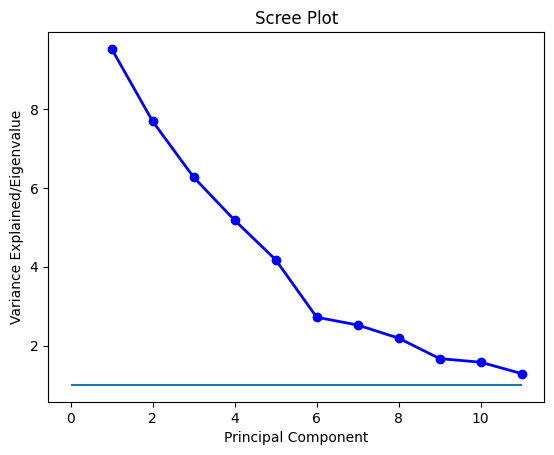

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(pca.explained_variance_))
plt.show()

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

pca_df = pd.DataFrame(data=loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(pca_df)
pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/joint_pca_analysis.xlsx')

                            PC1       PC2       PC3       PC4       PC5  \
informativeness        0.812573  0.175628  0.124564 -0.214450  0.123054   
constructive_feedback  0.217737  0.550465 -0.102610  0.089180  0.237668   
author_revelation     -0.208703  0.502256  0.158118  0.367020  0.240773   
comprehensibility      0.359558  0.178115  0.157254  0.441958 -0.390074   
detail_level           0.617651  0.228511  0.400227 -0.304042  0.122951   
...                         ...       ...       ...       ...       ...   
context-first          0.055174  0.210191  0.224708 -0.479964  0.127459   
setting-first          0.134409  0.091405  0.358209 -0.377699 -0.045305   
chronological          0.091797  0.093820  0.496717 -0.323452 -0.143456   
transition_level       0.185979  0.333396  0.379026 -0.381160  0.113599   
causal_level           0.192568  0.352809  0.218199 -0.180628  0.327622   

                            PC6       PC7       PC8       PC9      PC10  \
informativeness        0

In [ ]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=11, rotation='varimax')
X_fa = fa.fit_transform(X_norm)

rotated_loadings = fa.components_.T


print(fa.components_)

rotated_pca_df = pd.DataFrame(data=rotated_loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(rotated_pca_df)
rotated_pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/joint_rotated_pca_analysis.xlsx')

[[-4.84659972e-02 -1.05788540e-01 -2.53201917e-02  2.77784465e-02
   1.89397374e-01 -3.67429552e-02  6.52827363e-03 -2.02298966e-01
  -5.90205334e-02  3.90953857e-01 -6.11750341e-02 -1.24696076e-02
  -1.01976024e-01 -2.11388470e-02  3.43805708e-02 -1.73243533e-02
   8.67335138e-03 -5.31853991e-03  6.65853760e-03  1.92275818e-02
  -2.53726801e-02  1.76744410e-02 -9.41984366e-03  3.79994004e-02
   1.01712822e-02 -1.75305191e-02  7.93642325e-02  1.34638083e-01
  -1.39970544e-03 -2.32743089e-02  5.78169503e-04 -4.43969086e-02
  -1.05713760e-01 -4.80346851e-02  2.57071198e-01  3.38593826e-01
   2.44519192e-01 -9.12117811e-02 -8.74474552e-03 -1.23363048e-01
   3.41913313e-02  1.44655687e-01 -2.97821796e-03 -1.53374857e-01
   1.49350365e-01  1.07045519e-01 -9.92214906e-02 -1.12743784e-02
  -8.91242125e-02 -7.22369300e-02  3.35338706e-02 -1.68177033e-02
   9.87425909e-01  9.87707572e-01 -1.00580185e-01  9.20416962e-01
   3.47465012e-02  3.66112499e-01 -6.38053068e-02  4.47918805e-02
   2.51567

In [ ]:
pc1_df = pca_df[['PC1']]
pc1_df = pc1_df[(pc1_df['PC1'] <= -0.5) | (pc1_df['PC1'] >= 0.5)]
pc1_df

,PC1
informativeness,0.812573
detail_level,0.617651
explicitness,0.712878
implied_meaning,-0.738734
creative_text,-0.536998
expressfulness,-0.538998
vagueness,-0.604041
matter_of_factness,0.842933
figurativeness,-0.521701
concreteness,0.603489


In [ ]:
rotated_pc1_df = rotated_pca_df[['PC1']]
rotated_pc1_df = rotated_pc1_df[(rotated_pc1_df['PC1'] <= -0.5) | (rotated_pc1_df['PC1'] >= 0.5)]
rotated_pc1_df

,PC1
narrative,0.987426
narrative_mode,0.987708
storytelling,0.920417


In [ ]:
pc2_df = pca_df[['PC2']]
pc2_df = pc2_df[(pc2_df['PC2'] <= -0.5) | (pc2_df['PC2'] >= 0.5)]
pc2_df

,PC2
constructive_feedback,0.550465
author_revelation,0.502256
persuasiveness,0.575121
supportiveness,0.705781
empathy,0.628780
group_harmony,0.628715
group_wellbeing,0.514103
critique,0.507861
conflict,0.660522
prosociality,0.753953


In [ ]:
rotated_pc2_df = rotated_pca_df[['PC2']]
rotated_pc2_df = rotated_pc2_df[(rotated_pc2_df['PC2'] <= -0.5) | (rotated_pc2_df['PC2'] >= 0.5)]
rotated_pc2_df

,PC2
informativeness,-0.817581
detail_level,-0.745293
logical_reasoning,-0.541196
formality,-0.617515
exposition,-0.967717
expository_mode,-0.951316


In [ ]:
pc3_df = pca_df[['PC3']]
pc3_df = pc3_df[(pc3_df['PC3'] <= -0.5) | (pc3_df['PC3'] >= 0.5)]
pc3_df

,PC3
vividness,0.634897
expressfulness,0.530354
narrative,0.723843
narrative_mode,0.721625
storytelling,0.688518
showing,0.620407


In [ ]:
rotated_pc3_df = rotated_pca_df[['PC3']]
rotated_pc3_df = rotated_pc3_df[(rotated_pc3_df['PC3'] <= -0.5) | (rotated_pc3_df['PC3'] >= 0.5)]
rotated_pc3_df

,PC3
creative_text,0.937494
vividness,0.713236
expressfulness,0.647491
figurativeness,0.929131


In [ ]:
pc4_df = pca_df[['PC4']]
pc4_df = pc4_df[(pc4_df['PC4'] <= -0.5) | (pc4_df['PC4'] >= 0.5)]
pc4_df

,PC4
directness,0.558887
bluntness,0.642753


In [ ]:
pc5_df = pca_df[['PC5']]
pc5_df = pc5_df[(pc5_df['PC5'] <= -0.5) | (pc5_df['PC5'] >= 0.5)]
pc5_df

,PC5
right_wrong,0.507875
tactful,-0.548099
challenge,0.604958


In [ ]:
pc6_df = pca_df[['PC6']]
pc6_df = pc6_df[(pc6_df['PC6'] <= -0.5) | (pc6_df['PC6'] >= 0.5)]
pc6_df

,PC6
creative_text,0.529769
figurativeness,0.541688


In [ ]:
pc7_df = pca_df[['PC7']]
pc7_df = pc7_df[(pc7_df['PC7'] <= -0.3) | (pc7_df['PC7'] >= 0.3)]
pc7_df

,PC7
context_dependence,0.311948
status_suggestion,0.528622
status_appropriateness,0.446729
shared_responsibility,0.395399
group_wellbeing,0.326138
ext_responsibility,0.477689
other_reliance,0.505833


In [ ]:
pc8_df = pca_df[['PC8']]
pc8_df = pc8_df[(pc8_df['PC8'] <= -0.3) | (pc8_df['PC8'] >= 0.3)]
pc8_df

,PC8
personal_choice,0.362791
self-reliance,0.664572
self_growth,0.524938
self_responsibility,0.590836
accomplish_tasks,0.467468


In [ ]:
pc9_df = pca_df[['PC9']]
pc9_df = pc9_df[(pc9_df['PC9'] <= -0.3) | (pc9_df['PC9'] >= 0.3)]
pc9_df

,PC9
tradition,0.445039
status_suggestion,0.461127
status_appropriateness,0.391145
shared_responsibility,-0.312347
group_wellbeing,-0.323721
cultural-relatedness,0.434011


In [ ]:
pc10_df = pca_df[['PC10']]
pc10_df = pc10_df[(pc10_df['PC10'] <= -0.3) | (pc10_df['PC10'] >= 0.3)]
pc10_df

,PC10
comprehensibility,0.311644
anecdotal_reasoning,-0.327284
build_connection,-0.371310
conciseness,0.478837
verbosity,-0.364579


# Correlation Analysis (Chinese)

In [ ]:
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from sklearn import metrics

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [20]:
## Loading Chinese feature tables
chinese_joint_metadiscourse_df.drop(columns=['Unnamed: 0'], inplace=True)
chinese_joint_metadiscourse_df.rename(columns={'utterance_id': 'message_id'}, inplace=True)
chinese_joint_metadiscourse_df.head()

,message_id,utterance,avg_labeled_utterance,labeled_utterance,frame_markers,situation_dependent_references,chronological_markers,explicit_references,code_glosses,transitions,...,during,in_addition,even,you,in_advance,consider,even_though,as_long_as,can,in_the_same_way
0,u1984,介绍他如何提出了它，当时的人们如何反应，这件事如何影响了爱因斯坦的人生轨迹。 到“主要科學成...,3.0,介绍<frame_markers>他<situation_dependent_referen...,0.043956,0.032967,0.010989,0.010989,0.010989,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,u721,裁覆是說舉報內容非編輯破懷。 但如有人貼入侵權內容就是達舉報條件，不需3RR，只因侵權是很嚴...,4.0,裁覆是說舉報內容非編輯破懷。 但<transitions>如有人貼入侵權內容就是達舉報條件，...,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,u2503,會不會有人堅持(比如說該模板的一些編輯)認為台灣是中華人民共和國的一部分導致堅持要納入？ 現...,4.0,會不會有人堅持(比如說<code_glosses>該模板的一些編輯)認為台灣是中華人民共和國...,0.010309,0.000000,0.000000,0.000000,0.010309,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,u2963,删除了这句:在他们的影响下，一些外国的朋友也跃跃欲试。。 因在新浪访问中，他们说过我们这个灵...,2.0,删除了这句:在他们的影响下，一些外国的朋友也<transitions>跃跃欲试。。 因<ca...,0.000000,0.000000,0.000000,0.000000,0.011111,0.022222,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,u1411,抱歉回复晚了，首先谢谢你的意见。 不过我们在这里讨论，不用于编辑。 可以有各有各的色彩，少拿...,2.0,抱歉回复晚了，首先<frame_markers>谢谢你的<engagement_marker...,0.014286,0.000000,0.000000,0.000000,0.000000,0.014286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
chinese_joint_style_df.drop(columns=['Unnamed: 0', 'orientation'], inplace=True)
chinese_joint_style_df.head()

,message_id,informativeness,constructive_feedback,author_revelation,comprehensibility,detail_level,explicitness,context_dependence,persuasiveness,logical_reasoning,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
0,u1984,5,2,2,6,4,5,5,1,2,...,1,1,6,3,4,5,4,5,5,5
1,u721,6,3,2,6,3,6,5,3,4,...,1,2,6,2,1,3,3,1,1,4
2,u2503,4,5,4,6,4,4,6,4,3,...,1,4,5,3,2,5,3,1,2,4
3,u2963,6,2,4,6,5,6,5,3,4,...,1,2,6,3,2,4,4,3,4,5
4,u1411,4,3,4,7,2,5,5,3,2,...,1,4,7,4,2,4,4,1,2,1


In [ ]:
chinese_metadiscourseStyleFeatures_df = pd.merge(chinese_joint_metadiscourse_df, chinese_joint_style_df, on='message_id', how='inner')

In [ ]:
print(chinese_metadiscourseStyleFeatures_df.dtypes)

message_id                object
utterance                 object
avg_labeled_utterance    float64
labeled_utterance         object
frame_markers            float64
                          ...   
context-first              int64
setting-first              int64
chronological              int64
transition_level           int64
causal_level               int64
Length: 126, dtype: object


In [ ]:
## Computing correlations for chinese_dataset
X = chinese_metadiscourseStyleFeatures_df.select_dtypes(include=['int64', 'float64'])
X= X[X.columns[~X.columns.str.contains('nan')]]
corr = X.corr(method='pearson')

# source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(35, 35))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap='RdBu', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot=True,cbar_kws={"shrink": .5})

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
## hierarchical clustering
corr

,avg_labeled_utterance,frame_markers,situation_dependent_references,chronological_markers,explicit_references,code_glosses,transitions,causal_markers,adverbs_of_degree,hedges,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
avg_labeled_utterance,1.000000,0.013365,0.023044,0.001430,0.000936,0.037957,0.072355,0.059538,0.012681,0.074654,...,0.181826,-0.074668,-0.490283,0.084913,0.063861,0.091314,0.000522,-0.033934,-0.010447,-0.034279
frame_markers,0.013365,1.000000,-0.032102,0.030695,-0.042018,-0.032921,-0.031970,-0.034762,-0.032278,-0.024227,...,0.050673,0.033807,-0.002667,0.003901,-0.044165,0.018644,0.010906,0.017693,0.023761,-0.047857
situation_dependent_references,0.023044,-0.032102,1.000000,-0.013029,0.073505,-0.024632,-0.032157,-0.023013,0.032929,0.003619,...,-0.005764,-0.027520,-0.002733,-0.042527,-0.008608,-0.045537,-0.018705,-0.019644,-0.072792,-0.060413
chronological_markers,0.001430,0.030695,-0.013029,1.000000,-0.017555,-0.017085,-0.047223,-0.012393,-0.035462,-0.029108,...,0.054315,-0.054992,0.009639,-0.036801,0.032784,0.120168,0.160537,0.330690,0.184905,-0.005350
explicit_references,0.000936,-0.042018,0.073505,-0.017555,1.000000,-0.041046,-0.092635,-0.068915,-0.025559,-0.068032,...,0.001661,-0.052103,0.053659,-0.056982,-0.057903,-0.061492,-0.003461,-0.028397,-0.087365,-0.116296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
context-first,0.091314,0.018644,-0.045537,0.120168,-0.061492,0.013547,-0.020684,0.053503,-0.056363,-0.019624,...,0.058788,0.083936,-0.088835,0.091597,0.191485,1.000000,0.706394,0.378658,0.460823,0.303458
setting-first,0.000522,0.010906,-0.018705,0.160537,-0.003461,-0.019791,-0.046703,-0.021368,-0.047111,-0.041795,...,0.087798,-0.029136,0.029491,0.034415,0.188040,0.706394,1.000000,0.440354,0.376284,0.131590
chronological,-0.033934,0.017693,-0.019644,0.330690,-0.028397,-0.032893,-0.006534,0.025305,-0.058185,-0.057323,...,0.158773,-0.032653,0.054753,0.073470,0.242961,0.378658,0.440354,1.000000,0.666402,0.220221
transition_level,-0.010447,0.023761,-0.072792,0.184905,-0.087365,-0.001303,0.108428,0.131817,-0.048418,-0.027475,...,0.103547,0.099400,0.014709,0.146444,0.228720,0.460823,0.376284,0.666402,1.000000,0.454174


In [ ]:
corr.to_csv("/content/drive/MyDrive/High and Low Context Files/Results/test_corr.csv")

In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
# drop columns that equal the list of names below
corr.drop(columns=['but', 'note', 'interactive', 'also', 'rather', 'yet', 'still', 'although', 'purpose', 'at_the_same_time', 'again', 'completely', 'nonetheless', 'surprisingly', 'almost', 'self-mentions', 'additionally', 'always', 'therefore', 'then', 'and', 'during', 'in_addition', 'even', 'you', 'in_advance', 'consider', 'even_though', 'as_long_as', 'can', 'in_the_same_way'], inplace=True)

# drop rows where the 1st column equals the list of names from above
corr = corr[~corr.index.isin(['but', 'note', 'interactive', 'also', 'rather', 'yet', 'still', 'although', 'purpose', 'at_the_same_time', 'again', 'completely', 'nonetheless', 'surprisingly', 'almost', 'self-mentions', 'additionally', 'always', 'therefore', 'then', 'and', 'during', 'in_addition', 'even', 'you', 'in_advance', 'consider', 'even_though', 'as_long_as', 'can', 'in_the_same_way'])]

corr.to_csv("/content/drive/MyDrive/High and Low Context Files/Results/chinese_joint_feature_correlation.csv")

In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
chinese_high_context_df = corr[['avg_labeled_utterance']]
chinese_high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)
chinese_high_context_df.to_excel("/content/drive/MyDrive/High and Low Context Files/Results/chinese_joint_context_correlation.xlsx")
print(chinese_high_context_df)

/tmp/ipython-input-3157380991.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chinese_high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)


                       avg_labeled_utterance
clarity                            -0.490283
explicitness                       -0.443956
comprehensibility                  -0.415496
matter_of_factness                 -0.386505
directness                         -0.332277
...                                      ...
indirect                            0.346866
vagueness                           0.393386
implied_meaning                     0.409969
context_dependence                  0.453001
avg_labeled_utterance               1.000000

[92 rows x 1 columns]


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
chinese_corr = pd.read_csv("/content/drive/MyDrive/High and Low Context Files/Results/chinese_joint_feature_correlation.csv", index_col = 0)

# Create a copy to modify
chinese_filtered_corr_matrix = chinese_corr.copy()

thresh = 0.65

chinese_corr_pairs = chinese_filtered_corr_matrix.abs().unstack().reset_index()
# or mask = coeff < thresh

# Rename columns for clarity
chinese_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Remove self correlations
chinese_corr_pairs = chinese_corr_pairs[chinese_corr_pairs['Feature_1'] != chinese_corr_pairs['Feature_2']]

# To avoid duplicate pairs (A,B) and (B,A), sort features alphabetically and drop duplicates
chinese_corr_pairs['Ordered_Pair'] = chinese_corr_pairs.apply(lambda row: tuple(sorted([row['Feature_1'], row['Feature_2']])), axis=1)
chinese_corr_pairs = chinese_corr_pairs.drop_duplicates(subset=['Ordered_Pair'])

# Get the correlation with context level for each feature
chinese_corr_pairs['Feature_1_Context_Corr'] = chinese_corr_pairs['Feature_1'].map(chinese_high_context_df['avg_labeled_utterance'])
chinese_corr_pairs['Feature_2_Context_Corr'] = chinese_corr_pairs['Feature_2'].map(chinese_high_context_df['avg_labeled_utterance'])

# Return the feature name that has the lower absolute value correlation with the context level
chinese_corr_pairs['Lower_Context_Feature'] = chinese_corr_pairs.apply(lambda row: row['Feature_1'] if abs(row['Feature_1_Context_Corr']) < abs(row['Feature_2_Context_Corr']) else
                                                       "Tie" if abs(row['Feature_1_Context_Corr']) == abs(row['Feature_2_Context_Corr']) else row['Feature_2'], axis=1)

# Sort by absolute correlation descending
chinese_most_corr_pairs = chinese_corr_pairs[chinese_corr_pairs['Correlation'] >= thresh]
chinese_most_corr_pairs = chinese_most_corr_pairs.sort_values(by='Correlation', ascending=False)
chinese_most_corr_pairs.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/chinese_joint_ordered_correlational_pairs.xlsx')


In [ ]:
# calculate Euclidean distance after taking absolute value
abs_dist = lambda u, v: np.sqrt(((np.abs(u)-np.abs(v))**2).sum())

sns.set(font_scale=1.5)
cg = sns.clustermap(corr, row_linkage=linkage(corr, metric=abs_dist), col_linkage=linkage(corr, metric=abs_dist), figsize=(40,40), cmap='RdBu', vmin=-1, vmax=1, center= 0, annot=True, cbar_kws={"shrink": .5})
cg.ax_row_dendrogram.set_visible(False)

Output hidden; open in https://colab.research.google.com to view.

## Chinese - Correlation Clustering/PCA

In [ ]:
chinese_labeled_context_input_df = chinese_joint_utterance_df
X = chinese_joint_style_df
X = X.drop(['message_id'], axis=1)

Y = chinese_labeled_context_input_df[['avg_labeled_utterance']]
Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 3 else 1)
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
995    1
996    0
997    0
998    1
999    1
Name: avg_labeled_utterance, Length: 5000, dtype: int64


In [ ]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=11)
X_pca = pca.fit_transform(X_norm)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

# note: first 11 components explain ~80.43% of total variance
# and follow Kaiser rule (>1 eigenvalue)

[9.2057771  8.40510613 5.86070386 5.02383263 4.26691543 2.64037632
 2.41213915 2.12249805 1.6453632  1.47685099 1.37067928]
[0.13737218 0.12542426 0.0874557  0.07496758 0.06367257 0.03940072
 0.03599488 0.03167274 0.02455275 0.02203814 0.02045381]


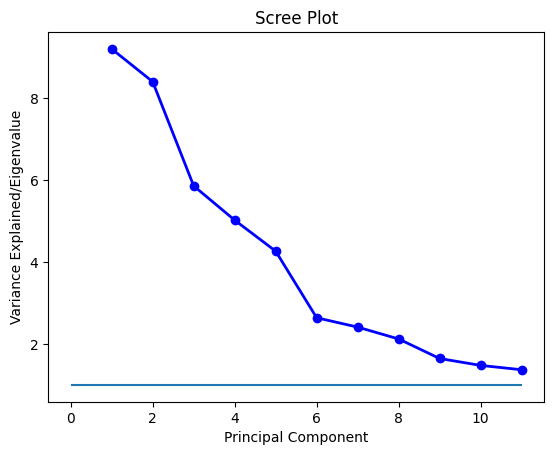

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(pca.explained_variance_))
plt.show()

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

pca_df = pd.DataFrame(data=loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(pca_df)
pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/chinese_joint_pca_analysis.xlsx')

                            PC1       PC2       PC3       PC4       PC5  \
informativeness        0.783584  0.311507  0.141155 -0.145037  0.101721   
constructive_feedback  0.136832  0.572180 -0.106710  0.138450  0.219325   
author_revelation     -0.331639  0.424222  0.082605  0.451841  0.157377   
comprehensibility      0.309334  0.037178  0.096171  0.424181 -0.442544   
detail_level           0.559283  0.366765  0.409923 -0.177756  0.110986   
...                         ...       ...       ...       ...       ...   
context-first          0.059622  0.348563  0.266729 -0.406405  0.124955   
setting-first          0.108231  0.142444  0.361730 -0.340559 -0.043171   
chronological          0.084194  0.140286  0.533423 -0.284030 -0.162105   
transition_level       0.121827  0.393363  0.433177 -0.312477  0.037210   
causal_level           0.161925  0.443186  0.190274 -0.120250  0.262952   

                            PC6       PC7       PC8       PC9      PC10  \
informativeness        0

In [ ]:
pc1_df = pca_df[['PC1']]
pc1_df = pc1_df[(pc1_df['PC1'] <= -0.5) | (pc1_df['PC1'] >= 0.5)]
pc1_df

,PC1
informativeness,0.783584
detail_level,0.559283
explicitness,0.645536
implied_meaning,-0.685315
creative_text,-0.522953
expressfulness,-0.596502
vagueness,-0.559509
matter_of_factness,0.847306
figurativeness,-0.521380
concreteness,0.562719


In [ ]:
pc2_df = pca_df[['PC2']]
pc2_df = pc2_df[(pc2_df['PC2'] <= -0.5) | (pc2_df['PC2'] >= 0.5)]
pc2_df

,PC2
constructive_feedback,0.572180
persuasiveness,0.605813
logical_reasoning,0.561376
supportiveness,0.654313
empathy,0.584105
group_harmony,0.612186
shared_responsibility,0.508590
group_wellbeing,0.529380
critique,0.583990
conflict,0.665879


In [ ]:
pc3_df = pca_df[['PC3']]
pc3_df = pc3_df[(pc3_df['PC3'] <= -0.5) | (pc3_df['PC3'] >= 0.5)]
pc3_df

,PC3
vividness,0.582694
narrative,0.754876
narrative_mode,0.754404
storytelling,0.710559
showing,0.595674
chronological,0.533423


In [ ]:
pc4_df = pca_df[['PC4']]
pc4_df = pc4_df[(pc4_df['PC4'] <= -0.5) | (pc4_df['PC4'] >= 0.5)]
pc4_df

,PC4
directness,0.512625
bluntness,0.624322


In [ ]:
pc5_df = pca_df[['PC5']]
pc5_df = pc5_df[(pc5_df['PC5'] <= -0.5) | (pc5_df['PC5'] >= 0.5)]
pc5_df

,PC5
tactful,-0.557484
challenge,0.580520


In [ ]:
pc6_df = pca_df[['PC6']]
pc6_df = pc6_df[(pc6_df['PC6'] <= -0.5) | (pc6_df['PC6'] >= 0.5)]
pc6_df

,PC6
creative_text,0.566154
figurativeness,0.582076


In [ ]:
pc7_df = pca_df[['PC7']]
pc7_df = pc7_df[(pc7_df['PC7'] <= -0.3) | (pc7_df['PC7'] >= 0.3)]
pc7_df

,PC7
status_suggestion,-0.492877
status_appropriateness,-0.410028
personal_choice,0.424998
self-reliance,0.525406
group_wellbeing,-0.333812
self_growth,0.390660
self_responsibility,0.405496
ext_responsibility,-0.373952
other_reliance,-0.361633


# All-Domain Analysis

## Cohen's D

In [ ]:
joint_cohen_df = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/english_chinese_joint_style_cohen_d.xlsx')
joint_cohen_df.rename(columns={'Unnamed: 0': 'feature', 0: 'joint'}, inplace=True)

subtitles_cohen_df = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/english_chinese_subtitles_style_cohen_d.xlsx')
subtitles_cohen_df.rename(columns={'Unnamed: 0': 'feature', 0: 'um_subtitles'}, inplace=True)

spoken_cohen_df = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/english_chinese_spoken_style_cohen_d.xlsx')
spoken_cohen_df.rename(columns={'Unnamed: 0': 'feature', 0: 'um_spoken'}, inplace=True)

testing_cohen_df = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/english_chinese_testing_style_cohen_d.xlsx')
testing_cohen_df.rename(columns={'Unnamed: 0': 'feature', 0: 'um_testing'}, inplace=True)

havaldar_cohen_df = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/english_chinese_style_cohen_d.xlsx')
havaldar_cohen_df.rename(columns={'Unnamed: 0': 'feature', 0: 'havaldar'}, inplace=True)

news_cohen_df = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/english_chinese_news_style_cohen_d.xlsx')
news_cohen_df.rename(columns={'Unnamed: 0': 'feature', 0: 'um_news'}, inplace=True)

combined_cohen_df = pd.merge(spoken_cohen_df, subtitles_cohen_df, on='feature', how='inner')
combined_cohen_df = pd.merge(combined_cohen_df, testing_cohen_df, on='feature', how='inner')
combined_cohen_df = pd.merge(combined_cohen_df, joint_cohen_df, on='feature', how='inner')
combined_cohen_df = pd.merge(combined_cohen_df, news_cohen_df, on='feature', how='inner')
combined_cohen_df = pd.merge(combined_cohen_df, havaldar_cohen_df, on='feature', how='inner')

combined_cohen_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_cohen_d.xlsx')
combined_cohen_df

,feature,um_spoken,um_subtitles,um_testing,joint,um_news,havaldar
0,clarity,-0.459024,-0.105465,-0.254294,-0.223305,-0.237850,-0.045519
1,directness,-0.457659,-0.239098,-0.267072,-0.251632,-0.228469,-0.035547
2,explicitness,-0.418963,-0.257417,-0.280097,-0.248531,-0.221949,-0.065521
3,comprehensibility,-0.343352,-0.036416,-0.217315,-0.153743,-0.192141,0.045076
4,matter_of_factness,-0.328609,-0.174587,-0.162255,-0.168531,-0.137057,-0.039482
...,...,...,...,...,...,...,...
62,critique,0.228736,0.228265,0.103470,0.153429,0.167591,0.072307
63,vagueness,0.327177,0.170025,0.316801,0.258024,0.320290,0.206061
64,context_dependence,0.331508,0.095727,0.188493,0.166865,0.240108,-0.033277
65,implied_meaning,0.432710,0.606890,0.360740,0.372462,0.352723,0.109145


## Correlation with Context-Level

In [ ]:
joint_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/joint_context_correlation.xlsx')
joint_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'joint'}, inplace=True)

subtitles_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/subtitles_context_correlation.xlsx')
subtitles_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'subtitles'}, inplace=True)

spoken_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/spoken_context_correlation.xlsx')
spoken_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'spoken'}, inplace=True)

testing_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/testing_context_correlation.xlsx')
testing_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'testing'}, inplace=True)

havaldar_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/context_correlation.xlsx')
havaldar_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'havaldar'}, inplace=True)

news_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/news_context_correlation.xlsx')
news_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'news'}, inplace=True)

In [ ]:
chinese_joint_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/chinese_joint_context_correlation.xlsx')
chinese_joint_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'chinese_joint'}, inplace=True)

chinese_subtitles_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_subtitles_context_correlation.xlsx')
chinese_subtitles_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'chinese_subtitles'}, inplace=True)

chinese_spoken_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_spoken_context_correlation.xlsx')
chinese_spoken_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'chinese_spoken'}, inplace=True)

chinese_testing_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_testing_context_correlation.xlsx')
chinese_testing_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'chinese_testing'}, inplace=True)

chinese_havaldar_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_context_correlation.xlsx')
chinese_havaldar_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'chinese_havaldar'}, inplace=True)

chinese_news_context_corr = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_news_context_correlation.xlsx')
chinese_news_context_corr.rename(columns={'Unnamed: 0': 'feature', 'avg_labeled_utterance': 'chinese_news'}, inplace=True)

In [ ]:
combined_context_level = pd.merge(spoken_context_corr, subtitles_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, testing_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, joint_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, news_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, havaldar_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, chinese_joint_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, chinese_subtitles_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, chinese_spoken_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, chinese_testing_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, chinese_news_context_corr, on='feature', how='inner')
combined_context_level = pd.merge(combined_context_level, chinese_havaldar_context_corr, on='feature', how='inner')

In [ ]:
# create a column that says 'True' if all numerical values in the row are < 0
combined_context_level['Always Low-Context'] = combined_context_level.apply(lambda row: 'True' if row['joint'] < 0 and row['subtitles'] < 0 and row['spoken'] < 0 and row['havaldar'] < 0 and row['testing'] < 0 and row['news'] < 0 and row['chinese_joint'] < 0 and row['chinese_subtitles'] < 0 and row['chinese_spoken'] < 0 and row['chinese_testing'] < 0 and row['chinese_havaldar'] < 0 and row['chinese_news'] < 0 else '', axis=1)
combined_context_level['Always High-Context'] = combined_context_level.apply(lambda row: 'True' if row['joint'] > 0 and row['subtitles'] > 0 and row['spoken'] > 0 and row['havaldar'] > 0 and row['testing'] > 0 and row['news'] > 0 and row['chinese_joint'] > 0 and row['chinese_subtitles'] > 0 and row['chinese_spoken'] > 0 and row['chinese_testing'] > 0 and row['chinese_havaldar'] > 0 and row['chinese_news'] > 0 else '', axis=1)
combined_context_level.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_context_correlation.xlsx')

## PCA

In [22]:
joint_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/joint_pca_analysis.xlsx')
joint_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'joint_PC1', 'PC2': 'joint_PC2', 'PC3': 'joint_PC3', 'PC4': 'joint_PC4', 'PC5': 'joint_PC5', 'PC6': 'joint_PC6', 'PC7': 'joint_PC7', 'PC8': 'joint_PC8', 'PC9': 'joint_PC9', 'PC10': 'joint_PC10', 'PC11': 'joint_PC11'}, inplace=True)

subtitles_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/subtitles_pca_analysis.xlsx')
subtitles_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'um_subtitles_PC1', 'PC2': 'um_subtitles_PC2', 'PC3': 'um_subtitles_PC3', 'PC4': 'um_subtitles_PC4', 'PC5': 'um_subtitles_PC5', 'PC6': 'um_subtitles_PC6', 'PC7': 'um_subtitles_PC7', 'PC8': 'um_subtitles_PC8', 'PC9': 'um_subtitles_PC9', 'PC10': 'um_subtitles_PC10', 'PC11': 'um_subtitles_PC11'}, inplace=True)

spoken_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/spoken_pca_analysis.xlsx')
spoken_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'um_spoken_PC1', 'PC2': 'um_spoken_PC2', 'PC3': 'um_spoken_PC3', 'PC4': 'um_spoken_PC4', 'PC5': 'um_spoken_PC5', 'PC6': 'um_spoken_PC6', 'PC7': 'um_spoken_PC7', 'PC8': 'um_spoken_PC8', 'PC9': 'um_spoken_PC9', 'PC10': 'um_spoken_PC10', 'PC11': 'um_spoken_PC11'}, inplace=True)

testing_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/testing_pca_analysis.xlsx')
testing_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'um_testing_PC1', 'PC2': 'um_testing_PC2', 'PC3': 'um_testing_PC3', 'PC4': 'um_testing_PC4', 'PC5': 'um_testing_PC5', 'PC6': 'um_testing_PC6', 'PC7': 'um_testing_PC7', 'PC8': 'um_testing_PC8', 'PC9': 'um_testing_PC9', 'PC10': 'um_testing_PC10', 'PC11': 'um_testing_PC11'}, inplace=True)

havaldar_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/pca_analysis.xlsx')
havaldar_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'havaldar_PC1', 'PC2': 'havaldar_PC2', 'PC3': 'havaldar_PC3', 'PC4': 'havaldar__PC4', 'PC5': 'havaldar_PC5', 'PC6': 'havaldar_PC6', 'PC7': 'havaldar_PC7', 'PC8': 'havaldar_PC8', 'PC9': 'havaldar_PC9', 'PC10': 'havaldar_PC10', 'PC11': 'havaldar_PC11'}, inplace=True)

news_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/news_pca_analysis.xlsx')
news_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'um_news_PC1', 'PC2': 'um_news_PC2', 'PC3': 'um_news_PC3', 'PC4': 'um_news_PC4', 'PC5': 'um_news_PC5', 'PC6': 'um_news_PC6', 'PC7': 'um_news_PC7', 'PC8': 'um_news_PC8', 'PC9': 'um_news_PC9', 'PC10': 'um_news_PC10', 'PC11': 'um_news_PC11'}, inplace=True)

In [23]:
chinese_joint_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/chinese_joint_pca_analysis.xlsx')
chinese_joint_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'chinese_joint_PC1', 'PC2': 'chinese_joint_PC2', 'PC3': 'chinese_joint_PC3', 'PC4': 'chinese_joint_PC4', 'PC5': 'chinese_joint_PC5', 'PC6': 'chinese_joint_PC6', 'PC7': 'chinese_joint_PC7', 'PC8': 'chinese_joint_PC8', 'PC9': 'chinese_joint_PC9', 'PC10': 'chinese_joint_PC10', 'PC11': 'chinese_joint_PC11'}, inplace=True)

chinese_subtitles_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_subtitles_pca_analysis.xlsx')
chinese_subtitles_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'chinese_um_subtitles_PC1', 'PC2': 'chinese_um_subtitles_PC2', 'PC3': 'chinese_um_subtitles_PC3', 'PC4': 'chinese_um_subtitles_PC4', 'PC5': 'chinese_um_subtitles_PC5', 'PC6': 'chinese_um_subtitles_PC6', 'PC7': 'chinese_um_subtitles_PC7', 'PC8': 'chinese_um_subtitles_PC8', 'PC9': 'chinese_um_subtitles_PC9', 'PC10': 'chinese_um_subtitles_PC10', 'PC11': 'chinese_um_subtitles_PC11'}, inplace=True)

chinese_spoken_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_spoken_pca_analysis.xlsx')
chinese_spoken_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'chinese_um_spoken_PC1', 'PC2': 'chinese_um_spoken_PC2', 'PC3': 'chinese_um_spoken_PC3', 'PC4': 'chinese_um_spoken_PC4', 'PC5': 'chinese_um_spoken_PC5', 'PC6': 'chinese_um_spoken_PC6', 'PC7': 'chinese_um_spoken_PC7', 'PC8': 'chinese_um_spoken_PC8', 'PC9': 'chinese_um_spoken_PC9', 'PC10': 'chinese_um_spoken_PC10', 'PC11': 'chinese_um_spoken_PC11'}, inplace=True)

chinese_testing_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_testing_pca_analysis.xlsx')
chinese_testing_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'chinese_um_testing_PC1', 'PC2': 'chinese_um_testing_PC2', 'PC3': 'chinese_um_testing_PC3', 'PC4': 'chinese_um_testing_PC4', 'PC5': 'chinese_um_testing_PC5', 'PC6': 'chinese_um_testing_PC6', 'PC7': 'chinese_um_testing_PC7', 'PC8': 'chinese_um_testing_PC8', 'PC9': 'chinese_um_testing_PC9', 'PC10': 'chinese_um_testing_PC10', 'PC11': 'chinese_um_testing_PC11'}, inplace=True)

chinese_havaldar_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_pca_analysis.xlsx')
chinese_havaldar_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'chinese_havaldar_PC1', 'PC2': 'chinese_havaldar_PC2', 'PC3': 'chinese_havaldar_PC3', 'PC4': 'chinese_havaldar_PC4', 'PC5': 'chinese_havaldar_PC5', 'PC6': 'chinese_havaldar_PC6', 'PC7': 'chinese_havaldar_PC7', 'PC8': 'chinese_havaldar_PC8', 'PC9': 'chinese_havaldar_PC9', 'PC10': 'chinese_havaldar_PC10', 'PC11': 'chinese_havaldar_PC11'}, inplace=True)

chinese_news_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_news_pca_analysis.xlsx')
chinese_news_pca.rename(columns={'Unnamed: 0': 'feature', 'PC1': 'chinese_um_news_PC1', 'PC2': 'chinese_um_news_PC2', 'PC3': 'chinese_um_news_PC3', 'PC4': 'chinese_um_news_PC4', 'PC5': 'chinese_um_news_PC5', 'PC6': 'chinese_um_news_PC6', 'PC7': 'chinese_um_news_PC7', 'PC8': 'chinese_um_news_PC8', 'PC9': 'chinese_um_news_PC9', 'PC10': 'chinese_um_news_PC10', 'PC11': 'chinese_um_news_PC11'}, inplace=True)

In [ ]:
combined_pca = pd.merge(spoken_pca, subtitles_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, testing_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, joint_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, news_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, havaldar_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, chinese_spoken_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, chinese_subtitles_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, chinese_testing_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, chinese_joint_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, chinese_news_pca, on='feature', how='inner')
combined_pca = pd.merge(combined_pca, chinese_havaldar_pca, on='feature', how='inner')

combined_pca.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_pca.xlsx')

### PC1 Analysis

In [ ]:
# create combined_pc1 of only columns with pc1 in the column name and then drop all columns with PC10 or PC11 in the column names
combined_pc1 = combined_pca.filter(regex='PC1')
combined_pc1 = combined_pc1.drop(columns=['joint_PC10', 'joint_PC11', 'chinese_joint_PC10', 'chinese_joint_PC11'])
combined_pc1 = combined_pc1.drop(columns=['um_spoken_PC10', 'um_spoken_PC11', 'um_subtitles_PC10', 'um_subtitles_PC11', 'um_testing_PC10', 'um_testing_PC11', 'havaldar_PC10', 'havaldar_PC11', 'chinese_um_spoken_PC10', 'chinese_um_spoken_PC11', 'chinese_um_subtitles_PC10', 'chinese_um_subtitles_PC11', 'chinese_um_testing_PC10', 'chinese_um_testing_PC11', 'chinese_havaldar_PC10', 'chinese_havaldar_PC11'])

# keep only values in combined_pc1 that are >= 0.5, excluding feature column
combined_pc1 = combined_pc1[combined_pc1 >= 0.5]
# drop rows where all cells are equal to NaN
combined_pc1.dropna(how='all', axis=0, inplace=True)
# add feature column back in at the left
combined_pc1.insert(0, 'feature', combined_pca['feature'])

combined_pc1.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_pc1.xlsx')
combined_pc1

,feature,um_spoken_PC1,um_subtitles_PC1,um_testing_PC1,joint_PC1,um_news_PC1,um_news_PC10,um_news_PC11,havaldar_PC1,chinese_um_spoken_PC1,chinese_um_subtitles_PC1,chinese_um_testing_PC1,chinese_joint_PC1,chinese_um_news_PC1,chinese_um_news_PC10,chinese_um_news_PC11,chinese_havaldar_PC1
0,informativeness,0.730786,NaN,0.561589,0.812573,0.711407,NaN,NaN,NaN,0.733416,NaN,NaN,0.783584,0.655046,NaN,NaN,NaN
3,comprehensibility,NaN,0.574500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.624967,NaN,NaN,NaN,NaN,NaN,NaN
4,detail_level,NaN,NaN,NaN,0.617651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.559283,NaN,NaN,NaN,NaN
5,explicitness,0.694662,0.847582,NaN,0.712878,0.604542,NaN,NaN,NaN,0.683805,0.858043,NaN,0.645536,0.571543,NaN,NaN,NaN
12,supportiveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.791155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.776475
13,empathy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.737125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.757872
16,personal_choice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.529139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,group_harmony,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.733694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.704847
18,shared_responsibility,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.572353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.559194
20,group_wellbeing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.544686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.502055


In [ ]:
# same thing but for pc2
combined_pc2 = combined_pca.filter(regex='PC2')

combined_pc2 = combined_pc2[combined_pc2 >= 0.5]
combined_pc2.dropna(how='all', axis=0, inplace=True)
combined_pc2.insert(0, 'feature', combined_pca['feature'])

combined_pc2.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_pc2.xlsx')
combined_pc2

,feature,um_spoken_PC2,um_subtitles_PC2,um_testing_PC2,joint_PC2,um_news_PC2,havaldar_PC2,chinese_um_spoken_PC2,chinese_um_subtitles_PC2,chinese_um_testing_PC2,chinese_joint_PC2,chinese_um_news_PC2,chinese_havaldar_PC2
0,informativeness,NaN,NaN,0.510285,NaN,NaN,0.771139,NaN,NaN,0.575554,NaN,NaN,0.762560
1,constructive_feedback,0.504653,NaN,NaN,0.550465,0.529845,NaN,0.531671,NaN,NaN,0.572180,0.512059,NaN
2,author_revelation,NaN,NaN,NaN,0.502256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,detail_level,NaN,NaN,NaN,NaN,NaN,0.586963,NaN,NaN,NaN,NaN,NaN,0.532234
5,explicitness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.533564
7,persuasiveness,0.593200,NaN,0.550714,0.575121,0.611041,NaN,0.612919,NaN,0.521299,0.605813,0.592332,NaN
8,logical_reasoning,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.561376,NaN,NaN
12,supportiveness,0.698574,0.713357,0.566787,0.705781,0.628072,NaN,0.693064,0.744657,0.520307,0.654313,0.562221,NaN
13,empathy,0.628472,0.627233,NaN,0.628780,NaN,NaN,0.592353,0.751220,NaN,0.584105,NaN,NaN
17,group_harmony,0.635595,0.584745,0.585277,0.628715,NaN,NaN,0.622195,0.640518,NaN,0.612186,NaN,NaN


In [ ]:
# same thing as pc2 but for pc3
combined_pc3 = combined_pca.filter(regex='PC3')

combined_pc3 = combined_pc3[combined_pc3 >= 0.5]
combined_pc3.dropna(how='all', axis=0, inplace=True)
combined_pc3.insert(0, 'feature', combined_pca['feature'])

combined_pc3.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_pc3.xlsx')
combined_pc3

,feature,um_spoken_PC3,um_subtitles_PC3,um_testing_PC3,joint_PC3,um_news_PC3,havaldar_PC3,chinese_um_spoken_PC3,chinese_um_subtitles_PC3,chinese_um_testing_PC3,chinese_joint_PC3,chinese_um_news_PC3,chinese_havaldar_PC3
1,constructive_feedback,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.509715
2,author_revelation,NaN,0.585142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,detail_level,NaN,NaN,0.639175,NaN,NaN,NaN,NaN,NaN,0.653577,NaN,0.652584,NaN
7,persuasiveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.785579
8,logical_reasoning,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.612251
9,anecdotal_reasoning,NaN,NaN,NaN,NaN,NaN,0.562661,NaN,NaN,NaN,NaN,NaN,NaN
10,right_wrong,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.661143
32,challenge,NaN,0.527662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.657374
35,vividness,0.715327,NaN,NaN,0.634897,NaN,NaN,0.560403,0.664124,NaN,0.582694,NaN,NaN
36,expressfulness,0.660492,0.746227,NaN,0.530354,NaN,NaN,0.542561,0.689530,NaN,NaN,NaN,NaN


In [ ]:
combined_pc4 = combined_pca.filter(regex='PC4')

combined_pc4 = combined_pc4[combined_pc4 >= 0.5]
combined_pc4.dropna(how='all', axis=0, inplace=True)
combined_pc4.insert(0, 'feature', combined_pca['feature'])

combined_pc4.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_pc4.xlsx')
combined_pc4

,feature,um_spoken_PC4,um_subtitles_PC4,um_testing_PC4,joint_PC4,um_news_PC4,havaldar__PC4,chinese_um_spoken_PC4,chinese_um_subtitles_PC4,chinese_um_testing_PC4,chinese_joint_PC4,chinese_um_news_PC4,chinese_havaldar_PC4
3,comprehensibility,NaN,NaN,0.614834,NaN,NaN,NaN,NaN,NaN,0.594177,NaN,0.589130,NaN
4,detail_level,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.533842,NaN,NaN,NaN,NaN
42,formality,NaN,NaN,NaN,NaN,0.506388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,conciseness,NaN,NaN,0.508674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,verbosity,NaN,NaN,NaN,NaN,0.585458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,directness,NaN,NaN,0.512610,0.558887,NaN,NaN,NaN,NaN,NaN,0.512625,NaN,NaN
49,bluntness,0.527004,NaN,NaN,0.642753,NaN,NaN,0.535031,NaN,NaN,0.624322,NaN,NaN
52,narrative,NaN,0.600950,NaN,NaN,NaN,NaN,NaN,0.759354,NaN,NaN,NaN,0.766539
53,narrative_mode,NaN,0.596790,NaN,NaN,NaN,NaN,NaN,0.759841,NaN,NaN,NaN,0.768432
55,storytelling,NaN,0.551382,NaN,NaN,NaN,NaN,NaN,0.702715,NaN,NaN,NaN,0.673339


In [ ]:
combined_pc5 = combined_pca.filter(regex='PC5')

combined_pc5 = combined_pc5[combined_pc5 >= 0.5]
combined_pc5.dropna(how='all', axis=0, inplace=True)
combined_pc5.insert(0, 'feature', combined_pca['feature'])

combined_pc5.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_pc5.xlsx')
combined_pc5

,feature,um_spoken_PC5,um_subtitles_PC5,um_testing_PC5,joint_PC5,um_news_PC5,havaldar_PC5,chinese_um_spoken_PC5,chinese_um_subtitles_PC5,chinese_um_testing_PC5,chinese_joint_PC5,chinese_um_news_PC5,chinese_havaldar_PC5
8,logical_reasoning,NaN,NaN,0.512349,NaN,NaN,0.599618,0.512734,NaN,NaN,NaN,NaN,NaN
10,right_wrong,NaN,NaN,NaN,0.507875,0.647600,NaN,NaN,NaN,NaN,NaN,0.681049,NaN
29,point_faults,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.508840,NaN,NaN,NaN
30,tactful,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.620520,NaN,NaN,NaN
32,challenge,NaN,NaN,NaN,0.604958,0.586094,NaN,NaN,NaN,NaN,0.58052,0.578069,NaN
39,abstractness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.569524
47,politeness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.528915,NaN,NaN,NaN
49,bluntness,NaN,NaN,NaN,NaN,0.695682,NaN,NaN,NaN,NaN,NaN,0.744876,NaN


## Feature Means per Domain Dataset

In [ ]:
temp_joint_style_df = joint_style_df.copy()
temp_subtitles_style_df = subtitles_style_df.copy()
temp_spoken_style_df = spoken_style_df.copy()
temp_testing_style_df = testing_style_df.copy()
temp_havaldar_style_df = havaldar_style_df.copy()
temp_news_style_df = news_style_df.copy()

temp_chinese_joint_style_df = chinese_joint_style_df.copy()
temp_chinese_subtitles_style_df = chinese_subtitles_style_df.copy()
temp_chinese_spoken_style_df = chinese_spoken_style_df.copy()
temp_chinese_testing_style_df = chinese_testing_style_df.copy()
temp_chinese_havaldar_style_df = chinese_havaldar_style_df.copy()
temp_chinese_news_style_df = chinese_news_style_df.copy()

In [ ]:
temp_joint_metadiscourse_df = joint_metadiscourse_df.copy()
temp_subtitles_metadiscourse_df = subtitles_metadiscourse_df.copy()
temp_spoken_metadiscourse_df = spoken_metadiscourse_df.copy()
temp_testing_metadiscourse_df = testing_metadiscourse_df.copy()
temp_havaldar_metadiscourse_df = havaldar_metadiscourse_df.copy()
temp_news_metadiscourse_df = news_metadiscourse_df.copy()

temp_chinese_joint_metadiscourse_df = chinese_joint_metadiscourse_df.copy()
temp_chinese_subtitles_metadiscourse_df = chinese_subtitles_metadiscourse_df.copy()
temp_chinese_spoken_metadiscourse_df = chinese_spoken_metadiscourse_df.copy()
temp_chinese_testing_metadiscourse_df = chinese_testing_metadiscourse_df.copy()
temp_chinese_havaldar_metadiscourse_df = chinese_havaldar_metadiscourse_df.copy()
temp_chinese_news_metadiscourse_df = chinese_news_metadiscourse_df.copy()

In [ ]:
# get the mean per feature across all domains in the joint style feature sheet
# exclude the message_id column
# return a dataframe

# NOTE: FIND THE AVG POLITENESS PER DOMAIN AND SEE IF ALIGNS WITH GRAPH
joint_feature_means = temp_joint_style_df.drop(columns=['message_id']).mean().reset_index()
joint_feature_means.rename({'index': 'feature'}, inplace=True)
joint_feature_means.columns = ['feature', 'joint']
print(joint_feature_means)

subtitles_feature_means = temp_subtitles_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
subtitles_feature_means.rename({'index': 'feature'}, inplace=True)
subtitles_feature_means.columns = ['feature', 'subtitles']
print(subtitles_feature_means)

spoken_feature_means = temp_spoken_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
spoken_feature_means.rename({'index': 'feature'}, inplace=True)
spoken_feature_means.columns = ['feature', 'spoken']
print(spoken_feature_means)

testing_feature_means = temp_testing_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
testing_feature_means.rename({'index': 'feature'}, inplace=True)
testing_feature_means.columns = ['feature', 'testing']
print(testing_feature_means)

havaldar_feature_means = temp_havaldar_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
havaldar_feature_means.rename({'index': 'feature'}, inplace=True)
havaldar_feature_means.columns = ['feature', 'havaldar']
print(havaldar_feature_means)

news_feature_means = temp_news_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
news_feature_means.rename({'index': 'feature'}, inplace=True)
news_feature_means.columns = ['feature', 'news']
print(news_feature_means)


                  feature   joint
0         informativeness  3.2994
1   constructive_feedback  1.5146
2       author_revelation  2.5904
3       comprehensibility  6.2104
4            detail_level  2.4428
..                    ...     ...
62          context-first  2.4706
63          setting-first  1.8616
64          chronological  1.6528
65       transition_level  1.8920
66           causal_level  2.2972

[67 rows x 2 columns]
                  feature  subtitles
0         informativeness      2.185
1   constructive_feedback      1.144
2       author_revelation      2.984
3       comprehensibility      6.277
4            detail_level      1.488
..                    ...        ...
62          context-first      2.055
63          setting-first      1.507
64          chronological      1.450
65       transition_level      1.447
66           causal_level      1.743

[67 rows x 2 columns]
                  feature  spoken
0         informativeness   2.688
1   constructive_feedback   1.149


In [ ]:
temp_joint_metadiscourse_df = temp_joint_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
temp_joint_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
temp_joint_metadiscourse_df.columns = ['feature', 'joint']
temp_joint_metadiscourse_df['feature'] = temp_joint_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(temp_joint_metadiscourse_df)

temp_subtitles_metadiscourse_df = temp_subtitles_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
temp_subtitles_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
temp_subtitles_metadiscourse_df.columns = ['feature', 'subtitles']
temp_subtitles_metadiscourse_df['feature'] = temp_subtitles_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(temp_subtitles_metadiscourse_df)

temp_spoken_metadiscourse_df = temp_spoken_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
temp_spoken_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
temp_spoken_metadiscourse_df.columns = ['feature', 'spoken']
temp_spoken_metadiscourse_df['feature'] = temp_spoken_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(temp_spoken_metadiscourse_df)

temp_testing_metadiscourse_df = temp_testing_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
temp_testing_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
temp_testing_metadiscourse_df.columns = ['feature', 'testing']
temp_testing_metadiscourse_df['feature'] = temp_testing_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(temp_testing_metadiscourse_df)

temp_havaldar_metadiscourse_df = temp_havaldar_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
temp_havaldar_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
temp_havaldar_metadiscourse_df.columns = ['feature', 'havaldar']
temp_havaldar_metadiscourse_df['feature'] = temp_havaldar_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(temp_havaldar_metadiscourse_df)

temp_news_metadiscourse_df = temp_news_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
temp_news_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
temp_news_metadiscourse_df.columns = ['feature', 'news']
temp_news_metadiscourse_df['feature'] = temp_news_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(temp_news_metadiscourse_df)

         feature  joint
0  context_level  2.293
         feature  subtitles
0  context_level      2.931
         feature  spoken
0  context_level   2.576
         feature  testing
0  context_level    1.978
         feature  havaldar
0  context_level     2.162
         feature   news
0  context_level  1.818


In [ ]:
chinese_joint_feature_means = temp_chinese_joint_style_df.drop(columns=['message_id']).mean().reset_index()
chinese_joint_feature_means.rename({'index': 'feature'}, inplace=True)
chinese_joint_feature_means.columns = ['feature', 'chinese_joint']
print(chinese_joint_feature_means)

chinese_subtitles_feature_means = temp_chinese_subtitles_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
chinese_subtitles_feature_means.rename({'index': 'feature'}, inplace=True)
chinese_subtitles_feature_means.columns = ['feature', 'chinese_subtitles']
print(chinese_subtitles_feature_means)

chinese_spoken_feature_means = temp_chinese_spoken_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
chinese_spoken_feature_means.rename({'index': 'feature'}, inplace=True)
chinese_spoken_feature_means.columns = ['feature', 'chinese_spoken']
print(chinese_spoken_feature_means)

chinese_testing_feature_means = temp_chinese_testing_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
chinese_testing_feature_means.rename({'index': 'feature'}, inplace=True)
chinese_testing_feature_means.columns = ['feature', 'chinese_testing']
print(chinese_testing_feature_means)

chinese_havaldar_feature_means = temp_chinese_havaldar_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
chinese_havaldar_feature_means.rename({'index': 'feature'}, inplace=True)
chinese_havaldar_feature_means.columns = ['feature', 'chinese_havaldar']
print(chinese_havaldar_feature_means)

chinese_news_feature_means = temp_chinese_news_style_df.drop(columns=['Unnamed: 0', 'message_id', 'orientation']).mean().reset_index()
chinese_news_feature_means.rename({'index': 'feature'}, inplace=True)
chinese_news_feature_means.columns = ['feature', 'chinese_news']
print(chinese_news_feature_means)


                  feature  chinese_joint
0         informativeness         3.3576
1   constructive_feedback         1.5524
2       author_revelation         2.4916
3       comprehensibility         6.3542
4            detail_level         2.3386
..                    ...            ...
62          context-first         2.3770
63          setting-first         1.9394
64          chronological         1.6946
65       transition_level         1.8610
66           causal_level         2.3572

[67 rows x 2 columns]
                  feature  chinese_subtitles
0         informativeness              2.111
1   constructive_feedback              1.114
2       author_revelation              2.795
3       comprehensibility              6.314
4            detail_level              1.390
..                    ...                ...
62          context-first              1.748
63          setting-first              1.500
64          chronological              1.428
65       transition_level          

In [ ]:
chinese_temp_joint_metadiscourse_df = temp_chinese_joint_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
chinese_temp_joint_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
chinese_temp_joint_metadiscourse_df.columns = ['feature', 'chinese_joint']
chinese_temp_joint_metadiscourse_df['feature'] = chinese_temp_joint_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(chinese_temp_joint_metadiscourse_df)

chinese_temp_subtitles_metadiscourse_df = temp_chinese_subtitles_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
chinese_temp_subtitles_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
chinese_temp_subtitles_metadiscourse_df.columns = ['feature', 'chinese_subtitles']
chinese_temp_subtitles_metadiscourse_df['feature'] = chinese_temp_subtitles_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(chinese_temp_subtitles_metadiscourse_df)

chinese_temp_spoken_metadiscourse_df = temp_chinese_spoken_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
chinese_temp_spoken_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
chinese_temp_spoken_metadiscourse_df.columns = ['feature', 'chinese_spoken']
chinese_temp_spoken_metadiscourse_df['feature'] = chinese_temp_spoken_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(chinese_temp_spoken_metadiscourse_df)

chinese_temp_testing_metadiscourse_df = temp_chinese_testing_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
chinese_temp_testing_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
chinese_temp_testing_metadiscourse_df.columns = ['feature', 'chinese_testing']
chinese_temp_testing_metadiscourse_df['feature'] = chinese_temp_testing_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(chinese_temp_testing_metadiscourse_df)

chinese_temp_havaldar_metadiscourse_df = temp_chinese_havaldar_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
chinese_temp_havaldar_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
chinese_temp_havaldar_metadiscourse_df.columns = ['feature', 'chinese_havaldar']
chinese_temp_havaldar_metadiscourse_df['feature'] = chinese_temp_havaldar_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(chinese_temp_havaldar_metadiscourse_df)

chinese_temp_news_metadiscourse_df = temp_chinese_news_metadiscourse_df[['avg_labeled_utterance']].mean().reset_index()
chinese_temp_news_metadiscourse_df.rename(columns={'index': 'feature'}, inplace=True)
chinese_temp_news_metadiscourse_df.columns = ['feature', 'chinese_news']
chinese_temp_news_metadiscourse_df['feature'] = chinese_temp_news_metadiscourse_df['feature'].str.replace('avg_labeled_utterance', 'context_level')
print(chinese_temp_news_metadiscourse_df)

         feature  chinese_joint
0  context_level         1.8404
         feature  chinese_subtitles
0  context_level              2.313
         feature  chinese_spoken
0  context_level            1.88
         feature  chinese_testing
0  context_level            1.504
         feature  chinese_havaldar
0  context_level              2.05
         feature  chinese_news
0  context_level         1.455


In [ ]:
joint_feature_means = pd.concat([joint_feature_means, temp_joint_metadiscourse_df])
chinese_joint_feature_means = pd.concat([chinese_joint_feature_means, chinese_temp_joint_metadiscourse_df])
subtitles_feature_means = pd.concat([subtitles_feature_means, temp_subtitles_metadiscourse_df])
chinese_subtitles_feature_means = pd.concat([chinese_subtitles_feature_means, chinese_temp_subtitles_metadiscourse_df])
spoken_feature_means = pd.concat([spoken_feature_means, temp_spoken_metadiscourse_df])
chinese_spoken_feature_means = pd.concat([chinese_spoken_feature_means, chinese_temp_spoken_metadiscourse_df])
testing_feature_means = pd.concat([testing_feature_means, temp_testing_metadiscourse_df])
chinese_testing_feature_means = pd.concat([chinese_testing_feature_means, chinese_temp_testing_metadiscourse_df])
havaldar_feature_means = pd.concat([havaldar_feature_means, temp_havaldar_metadiscourse_df])
chinese_havaldar_feature_means = pd.concat([chinese_havaldar_feature_means, chinese_temp_havaldar_metadiscourse_df])
news_feature_means = pd.concat([news_feature_means, temp_news_metadiscourse_df])
chinese_news_feature_means = pd.concat([chinese_news_feature_means, chinese_temp_news_metadiscourse_df])

In [ ]:
combined_feature_means = pd.merge(spoken_feature_means, subtitles_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, testing_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, joint_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, news_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, havaldar_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, chinese_spoken_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, chinese_subtitles_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, chinese_testing_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, chinese_joint_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, chinese_news_feature_means, on='feature', how='inner')
combined_feature_means = pd.merge(combined_feature_means, chinese_havaldar_feature_means, on='feature', how='inner')

# combined_feature_means.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_feature_means.xlsx')
combined_feature_means

,feature,spoken,subtitles,testing,joint,news,havaldar,chinese_spoken,chinese_subtitles,chinese_testing,chinese_joint,chinese_news,chinese_havaldar
0,informativeness,2.688,2.185,3.403,3.2994,3.911,4.310,2.855,2.111,3.579,3.3576,3.988,4.255
1,constructive_feedback,1.149,1.144,1.221,1.5146,1.331,2.728,1.196,1.114,1.232,1.5524,1.327,2.893
2,author_revelation,2.139,2.984,1.950,2.5904,2.128,3.751,2.122,2.795,1.887,2.4916,2.082,3.572
3,comprehensibility,5.949,6.277,6.244,6.2104,6.283,6.299,6.296,6.314,6.441,6.3542,6.455,6.265
4,detail_level,1.845,1.488,2.433,2.4428,2.959,3.489,1.854,1.390,2.369,2.3386,2.908,3.172
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,setting-first,1.707,1.507,1.832,1.8616,2.192,2.070,1.844,1.500,1.995,1.9394,2.263,2.095
64,chronological,1.641,1.450,1.583,1.6528,1.800,1.790,1.683,1.428,1.645,1.6946,1.932,1.785
65,transition_level,1.665,1.447,1.689,1.8920,2.015,2.644,1.672,1.344,1.795,1.8610,2.131,2.363
66,causal_level,1.959,1.743,2.205,2.2972,2.521,3.058,2.060,1.646,2.321,2.3572,2.654,3.105


In [ ]:

# get simplified domain feature means, which gets the average between the english and chinese means per domain from the above code

simplified_feature_means = pd.DataFrame({})

# list the English + Chinese column pairs
pairs = [
    ('spoken', 'chinese_spoken'),
    ('subtitles', 'chinese_subtitles'),
    ('testing', 'chinese_testing'),
    ('joint', 'chinese_joint'),
    ('news', 'chinese_news'),
    ('havaldar', 'chinese_havaldar')
]

# create the averaged columns
for eng, chi in pairs:
    simplified_feature_means[f'{eng}_avg'] = combined_feature_means[[eng, chi]].mean(axis=1)

# make a simplified dataframe: keep feature + new averages
simplified_feature_means.insert(0, 'feature', combined_feature_means['feature'])
# simplified_feature_means.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/simplified_feature_means.xlsx')
simplified_feature_means

,feature,spoken_avg,subtitles_avg,testing_avg,joint_avg,news_avg,havaldar_avg
0,informativeness,2.7715,2.1480,3.4910,3.3285,3.9495,4.2825
1,constructive_feedback,1.1725,1.1290,1.2265,1.5335,1.3290,2.8105
2,author_revelation,2.1305,2.8895,1.9185,2.5410,2.1050,3.6615
3,comprehensibility,6.1225,6.2955,6.3425,6.2823,6.3690,6.2820
4,detail_level,1.8495,1.4390,2.4010,2.3907,2.9335,3.3305
...,...,...,...,...,...,...,...
63,setting-first,1.7755,1.5035,1.9135,1.9005,2.2275,2.0825
64,chronological,1.6620,1.4390,1.6140,1.6737,1.8660,1.7875
65,transition_level,1.6685,1.3955,1.7420,1.8765,2.0730,2.5035
66,causal_level,2.0095,1.6945,2.2630,2.3272,2.5875,3.0815


In [ ]:
# get bilingual domain feature means, which gets the average between the english and chinese means per domain from the above code

bilingual_feature_means = pd.DataFrame({})

# list the English + Chinese column pairs
pairs = [
    ('spoken', 'subtitles', 'testing', 'joint', 'news', 'havaldar'),
    ('chinese_spoken', 'chinese_subtitles', 'chinese_testing', 'chinese_joint', 'chinese_news', 'chinese_havaldar')
]

# create the averaged columns
for one, two, three, four, five, six in pairs:
    bilingual_feature_means[f'{one}_avg'] = combined_feature_means[[one, two, three, four, five, six]].mean(axis=1)

# make a simplified dataframe: keep feature + new averages
bilingual_feature_means.insert(0, 'feature', combined_feature_means['feature'])
bilingual_feature_means.rename(columns={'spoken_avg': 'english', 'chinese_spoken_avg': 'chinese'}, inplace=True)
bilingual_feature_means.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/bilingual_feature_means.xlsx')
bilingual_feature_means

,feature,english,chinese
0,informativeness,3.2994,3.3576
1,constructive_feedback,1.5146,1.5524
2,author_revelation,2.5904,2.4916
3,comprehensibility,6.2104,6.3542
4,detail_level,2.4428,2.3386
...,...,...,...
63,setting-first,1.8616,1.9394
64,chronological,1.6528,1.6946
65,transition_level,1.8920,1.8610
66,causal_level,2.2972,2.3572


# Graphs for Paper

In [ ]:
# reduce context_correlation down to just the ones that are all Low-Context or all High-Context
context_correlation = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_context_correlation.xlsx')
context_correlation = context_correlation[(context_correlation['Always Low-Context'] == True) | (context_correlation['Always High-Context'] == True)]
context_correlation.drop(columns=['Unnamed: 0'], inplace=True)
print(context_correlation)

# reduce cohen's d features down to just the features in context_correlation
cohen_d = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_cohen_d.xlsx')
cohen_d = cohen_d[cohen_d['feature'].isin(context_correlation['feature'])]
cohen_d.drop(columns=['Unnamed: 0'], inplace=True)
print(cohen_d)

                  feature    spoken  subtitles   testing     joint      news  \
0                 clarity -0.670088  -0.568364 -0.447014 -0.486743 -0.464139   
1            explicitness -0.666716  -0.522649 -0.471391 -0.472845 -0.450513   
2              directness -0.568126  -0.378411 -0.322537 -0.354739 -0.431860   
3       comprehensibility -0.550173  -0.430024 -0.257163 -0.348551 -0.349267   
4      matter_of_factness -0.522019  -0.331040 -0.479231 -0.416433 -0.386301   
5         informativeness -0.485235  -0.243055 -0.410779 -0.376733 -0.370674   
6            concreteness -0.475209  -0.415365 -0.362057 -0.345396 -0.312810   
7            detail_level -0.368606  -0.149848 -0.293831 -0.289601 -0.270646   
8         expository_mode -0.367699  -0.111466 -0.390433 -0.345965 -0.334141   
9              exposition -0.367337  -0.109775 -0.379365 -0.339658 -0.336399   
10              formality -0.363377  -0.078646 -0.329379 -0.320234 -0.188438   
14             politeness -0.150482  -0.

In [ ]:
# create a matplotlib graph that charts the always-low-context features' cohen's d across the domains
cohen_d_low = cohen_d[cohen_d['feature'].isin(context_correlation[context_correlation['Always Low-Context'] == True]['feature'])]
print(cohen_d_low)

low_dataset_cols = [col for col in cohen_d_low.columns if col != 'feature']
print(low_dataset_cols)


                  feature  um_spoken  um_subtitles  um_testing     joint  \
0                 clarity  -0.459024     -0.105465   -0.254294 -0.223305   
1              directness  -0.457659     -0.239098   -0.267072 -0.251632   
2            explicitness  -0.418963     -0.257417   -0.280097 -0.248531   
3       comprehensibility  -0.343352     -0.036416   -0.217315 -0.153743   
4      matter_of_factness  -0.328609     -0.174587   -0.162255 -0.168531   
5               formality  -0.300869     -0.093716   -0.088751 -0.167504   
7            concreteness  -0.240005     -0.154800   -0.235603 -0.165205   
9         informativeness  -0.152308      0.078817   -0.143348 -0.048095   
12           prosociality  -0.112091      0.078847   -0.062250 -0.042435   
13        expository_mode  -0.096548      0.065837   -0.064318 -0.040890   
15             exposition  -0.080652      0.065834   -0.066836 -0.027565   
16       accomplish_tasks  -0.078709      0.064117   -0.018313 -0.003599   
18          

In [ ]:
simplified_feature_means[simplified_feature_means['feature'] == 'politeness']

,feature,spoken_avg,subtitles_avg,testing_avg,joint_avg,news_avg,havaldar_avg
47,politeness,4.24,3.861,4.44,4.3521,4.578,4.6415


In [ ]:
simplified_feature_means[simplified_feature_means['feature'] == 'formality']

,feature,spoken_avg,subtitles_avg,testing_avg,joint_avg,news_avg,havaldar_avg
42,formality,3.5875,2.5185,4.623,3.8895,4.538,4.1805


In [ ]:
simplified_feature_means[simplified_feature_means['feature'] == 'prosociality']

,feature,spoken_avg,subtitles_avg,testing_avg,joint_avg,news_avg,havaldar_avg
58,prosociality,1.829,1.966,1.872,2.0178,1.957,2.465


In [ ]:
simplified_feature_means[simplified_feature_means['feature'] == 'exposition']

,feature,spoken_avg,subtitles_avg,testing_avg,joint_avg,news_avg,havaldar_avg
51,exposition,2.1645,1.294,3.0395,2.7747,3.5515,3.824


In [ ]:
simplified_feature_means[simplified_feature_means['feature'] == 'context_level']

,feature,spoken_avg,subtitles_avg,testing_avg,joint_avg,news_avg,havaldar_avg
67,context_level,2.228,2.622,1.741,2.0667,1.6365,2.106


In [ ]:
simplified_feature_means[simplified_feature_means['feature'] == 'informativeness']

,feature,spoken_avg,subtitles_avg,testing_avg,joint_avg,news_avg,havaldar_avg
0,informativeness,2.7715,2.148,3.491,3.3285,3.9495,4.2825


In [ ]:
first_cluster = ['informativeness', 'explicitness', 'concreteness', 'matter_of_factness', 'exposition', 'expository_mode', 'implied_meaning']

first_cluster_means = simplified_feature_means[simplified_feature_means['feature'].isin(first_cluster)].drop('feature', axis=1).mean()
first_cluster_means

,0
spoken_avg,3.382643
subtitles_avg,3.017500
testing_avg,3.920786
joint_avg,3.784671
news_avg,4.187286
havaldar_avg,4.415143


In [ ]:
second_cluster = ['supportiveness', 'empathy', 'group_harmony', 'shared_responsibility',
                  'group_wellbeing', 'prosociality', 'conflict']

second_cluster_means = simplified_feature_means[simplified_feature_means['feature'].isin(second_cluster)].drop('feature', axis=1).mean()
second_cluster_means

,0
spoken_avg,1.497500
subtitles_avg,1.618571
testing_avg,1.516786
joint_avg,1.627786
news_avg,1.588000
havaldar_avg,1.918071


In [ ]:
third_cluster = ['narrative', 'narrative_mode', 'storytelling', 'engagement', 'chronological', 'vividness', 'expressfulness']

third_cluster_means = simplified_feature_means[simplified_feature_means['feature'].isin(third_cluster)].drop('feature', axis=1).mean()
third_cluster_means

,0
spoken_avg,1.846857
subtitles_avg,1.854857
testing_avg,1.802429
joint_avg,1.865629
news_avg,2.025714
havaldar_avg,1.798286


In [ ]:
fourth_cluster = ['conciseness', 'comprehensibility', 'directness', 'clarity']

fourth_cluster_means = simplified_feature_means[simplified_feature_means['feature'].isin(fourth_cluster)].drop('feature', axis=1).mean()
fourth_cluster_means

,0
spoken_avg,5.879750
subtitles_avg,6.029875
testing_avg,6.089375
joint_avg,5.997150
news_avg,6.039375
havaldar_avg,5.947375


In [ ]:
fifth_cluster = ['challenge', 'right_wrong', 'bluntness']

fifth_cluster_means = simplified_feature_means[simplified_feature_means['feature'].isin(fifth_cluster)].drop('feature', axis=1).mean()
fifth_cluster_means

,0
spoken_avg,1.853667
subtitles_avg,2.168500
testing_avg,1.953500
joint_avg,2.181267
news_avg,1.974833
havaldar_avg,2.955833


In [ ]:
combined_feature_means[combined_feature_means['feature'] == 'context_level']

,feature,spoken,subtitles,testing,joint,news,havaldar,chinese_spoken,chinese_subtitles,chinese_testing,chinese_joint,chinese_news,chinese_havaldar
67,context_level,2.576,2.931,1.978,2.293,1.818,2.162,1.88,2.313,1.504,1.8404,1.455,2.05


In [ ]:
low_dataset_cols = ['um_spoken', 'um_testing', 'um_news', 'um_subtitles', 'joint', 'havaldar']

In [ ]:
# cohen_d_low = cohen_d_low[~cohen_d_low['feature'].isin(['tactful', 'self-reliance', 'self_responsibility', 'formality', 'prosociality', 'politeness', ])]
# cohen_d_low

,feature,um_spoken,um_subtitles,um_testing,joint,um_news,havaldar
0,clarity,-0.459024,-0.105465,-0.254294,-0.223305,-0.237850,-0.045519
1,directness,-0.457659,-0.239098,-0.267072,-0.251632,-0.228469,-0.035547
2,explicitness,-0.418963,-0.257417,-0.280097,-0.248531,-0.221949,-0.065521
3,comprehensibility,-0.343352,-0.036416,-0.217315,-0.153743,-0.192141,0.045076
4,matter_of_factness,-0.328609,-0.174587,-0.162255,-0.168531,-0.137057,-0.039482
7,concreteness,-0.240005,-0.154800,-0.235603,-0.165205,-0.140836,-0.049478
9,informativeness,-0.152308,0.078817,-0.143348,-0.048095,-0.065308,0.051933
13,expository_mode,-0.096548,0.065837,-0.064318,-0.040890,-0.046423,-0.055899
15,exposition,-0.080652,0.065834,-0.066836,-0.027565,-0.018023,-0.024416
16,accomplish_tasks,-0.078709,0.064117,-0.018313,-0.003599,-0.042371,0.053558


In [ ]:
cohen_d_low = cohen_d_low[cohen_d_low['feature'].isin(fourth_cluster)]
cohen_d_low

,feature,um_spoken,um_subtitles,um_testing,joint,um_news,havaldar


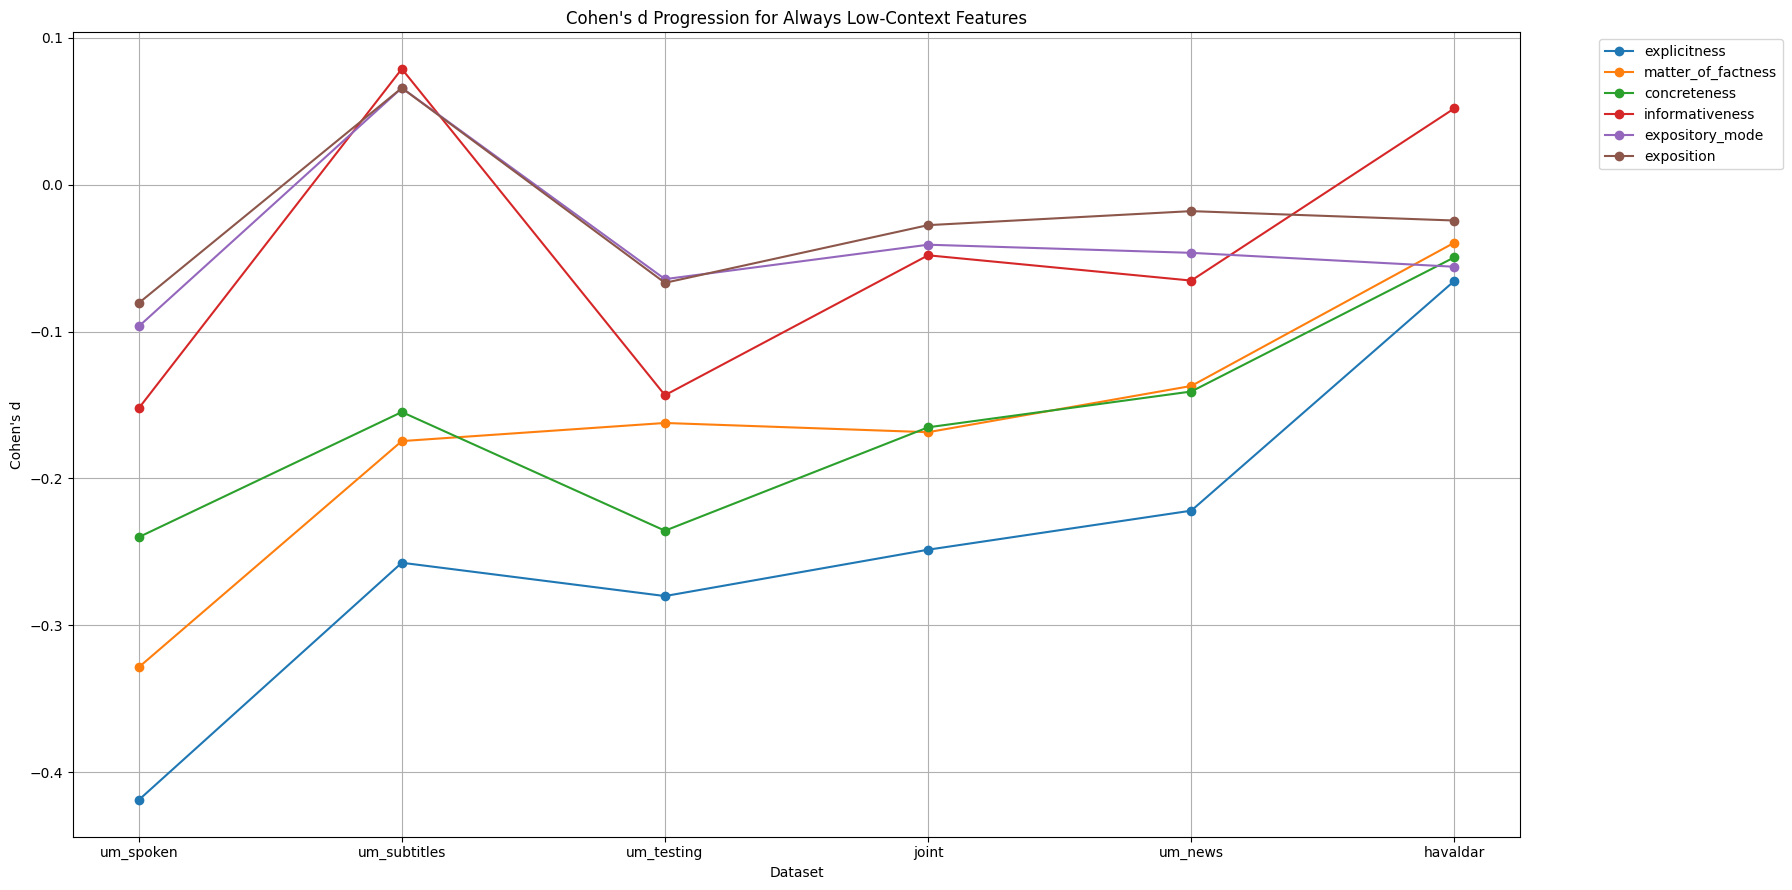

In [ ]:
plt.figure(figsize=(18,9))
for _, row in cohen_d_low.iterrows():
  plt.plot(low_dataset_cols, row[low_dataset_cols], marker='o', label=row["feature"])

plt.title("Cohen's d Progression for Always Low-Context Features")
plt.xlabel("Dataset")
plt.ylabel("Cohen's d")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
cohen_d_high = cohen_d[cohen_d['feature'].isin(context_correlation[context_correlation['Always High-Context'] == True]['feature'])]

high_dataset_cols = [col for col in cohen_d_high.columns if col != 'feature']

In [ ]:
high_dataset_cols = low_dataset_cols.copy()
# high_dataset_cols.reverse()
print(high_dataset_cols)

['um_spoken', 'um_subtitles', 'um_testing', 'joint', 'um_news', 'havaldar']


In [ ]:
cohen_d_high = cohen_d_high[cohen_d_high['feature'].isin(fourth_cluster)]
cohen_d_high

,feature,um_spoken,um_subtitles,um_testing,joint,um_news,havaldar


In [ ]:
cohen_d_high = cohen_d[cohen_d['feature'].isin(fourth_cluster)]
cohen_d_high

,feature,um_spoken,um_subtitles,um_testing,joint,um_news,havaldar
0,clarity,-0.459024,-0.105465,-0.254294,-0.223305,-0.237850,-0.045519
1,directness,-0.457659,-0.239098,-0.267072,-0.251632,-0.228469,-0.035547
3,comprehensibility,-0.343352,-0.036416,-0.217315,-0.153743,-0.192141,0.045076


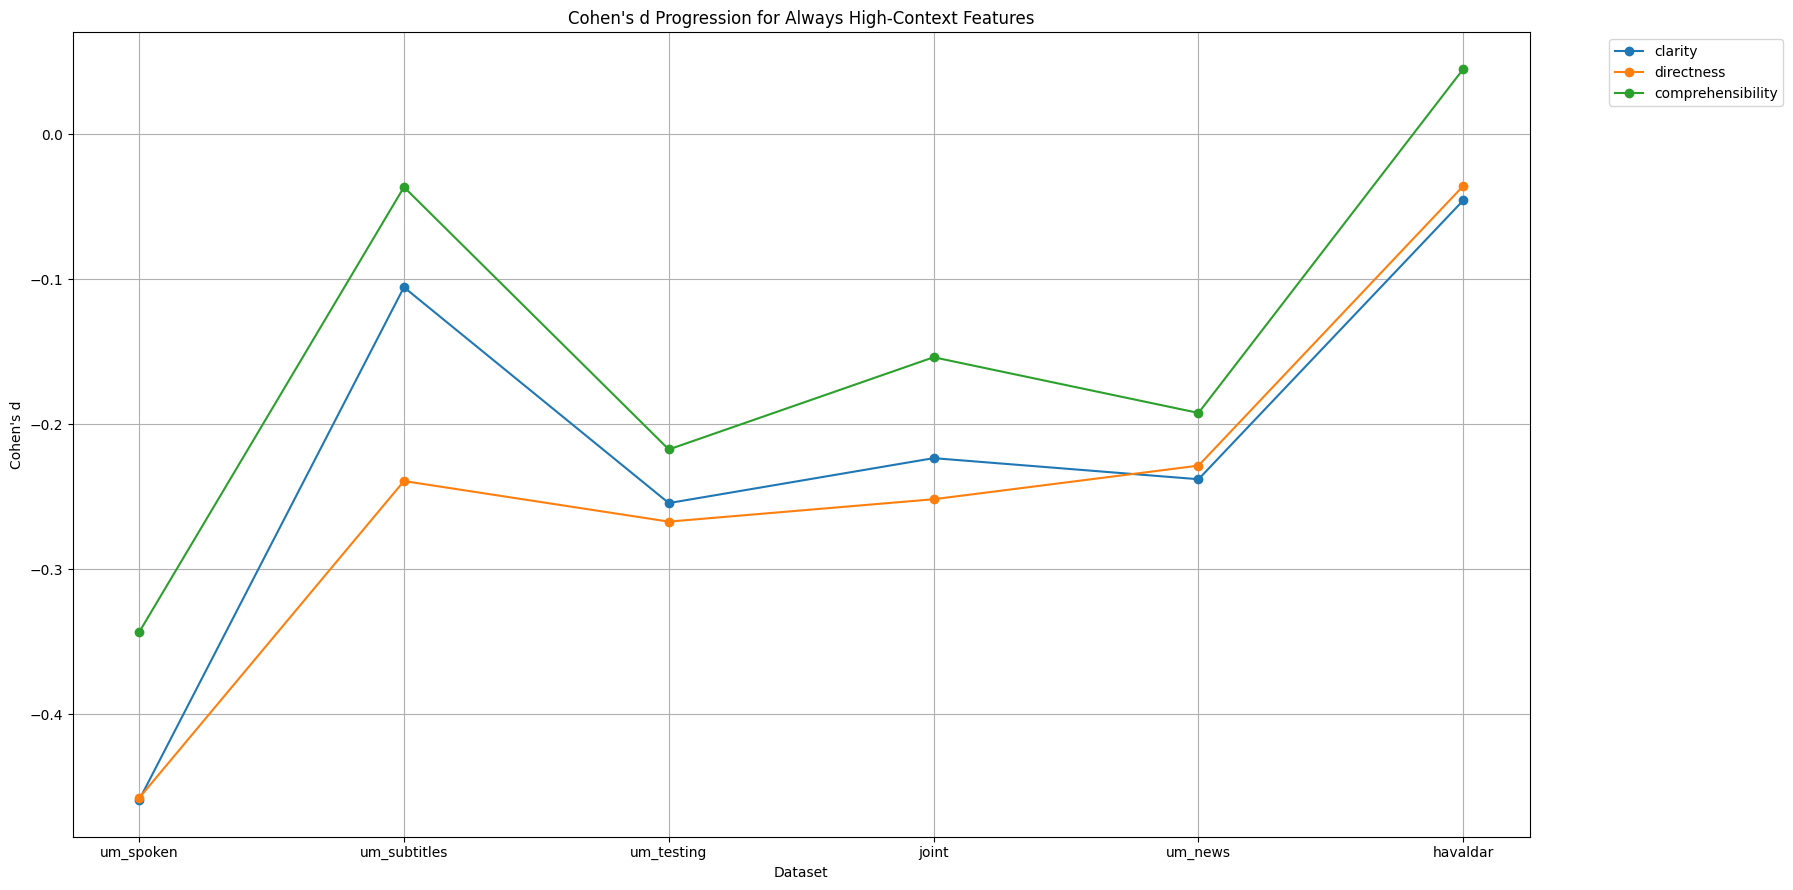

In [ ]:
plt.figure(figsize=(18,9))
for _, row in cohen_d_high.iterrows():
  plt.plot(high_dataset_cols, row[high_dataset_cols], marker='o', label=row["feature"])

plt.title("Cohen's d Progression for Always High-Context Features")
plt.xlabel("Dataset")
plt.ylabel("Cohen's d")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Cohen's D comparisons

In [ ]:
all_english = combined_cohen_df.copy()
# create a column that says 'True' if all cohen's d values are > 0
all_english['Always More English'] = all_english.apply(lambda row: 'True' if row['joint'] > 0 and row['um_subtitles'] > 0 and row['um_spoken'] > 0 and row['havaldar'] > 0 and row['um_testing'] > 0 and row['um_news'] > 0 else '', axis=1)
all_english['Always More Chinese'] = all_english.apply(lambda row: 'True' if row['joint'] < 0 and row['um_subtitles'] < 0 and row['um_spoken'] < 0 and row['havaldar'] < 0 and row['um_testing'] < 0 and row['um_news'] < 0 else '', axis=1)
all_english.to_excel('/content/drive/MyDrive/High and Low Context Files/Results/all_domain_english_or_chinese.xlsx')

# Logistic Regression

In [24]:
english_chinese_joint_style_df = pd.concat([joint_style_df, chinese_joint_style_df]).reset_index(drop=True)
english_chinese_joint_style_df

,message_id,informativeness,constructive_feedback,author_revelation,comprehensibility,detail_level,explicitness,context_dependence,persuasiveness,logical_reasoning,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
0,u1984,2,2,4,7,2,5,5,3,3,...,1,1,6,4,2,4,4,3,2,4
1,u721,2,3,4,7,2,3,6,2,2,...,1,4,6,3,2,4,3,4,4,2
2,u2503,5,3,2,6,4,5,5,3,4,...,1,2,6,3,2,4,4,4,4,2
3,u2963,5,4,3,6,4,6,3,4,4,...,1,2,6,3,2,3,1,1,2,2
4,u1411,4,5,5,6,2,5,6,4,4,...,1,2,6,4,3,4,1,2,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,u398483,3,4,4,7,2,5,6,4,2,...,1,3,6,3,2,2,1,1,1,1
9996,u296815,2,1,3,6,2,3,6,3,1,...,1,4,5,2,1,4,2,1,2,3
9997,u59255,5,1,4,6,5,6,2,4,3,...,1,1,6,4,2,2,1,1,2,5
9998,u444000,6,1,1,7,4,6,2,2,2,...,1,1,7,3,2,3,3,2,2,3


In [25]:
english_chinese_joint_metadiscourse_df = pd.concat([joint_metadiscourse_df, chinese_joint_metadiscourse_df]).reset_index(drop=True)
english_chinese_joint_metadiscourse_df

,message_id,utterance,avg_labeled_utterance,labeled_utterance,engagement_markers,hedges,attitude_markers,frame_markers,boosters,explicit_references,...,during,in_addition,even,you,in_advance,consider,even_though,as_long_as,can,in_the_same_way
0,u1984,"Spelunky (2008) by Derek Yu, The Binding of Is...",2.0,"Spelunky (2008) by Derek Yu, The Binding of Is...",0.002825,0.002825,0.002825,0.002825,0.002825,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,u721,this has been the most positive interaction I ...,3.0,this has been the most positive interaction I<...,0.000000,0.005780,0.000000,0.000000,0.000000,0.017341,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,u2503,"This statement has been added, removed and had...",2.0,This<explicit_references> statement has been a...,0.000000,0.000000,0.000000,0.000000,0.000000,0.007246,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,u2963,"in the English language, is this movement bett...",2.0,"in the English language<place_time_svo>, is th...",0.003663,0.000000,0.000000,0.000000,0.000000,0.010989,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,u1411,There are cases when more information does not...,3.0,There are cases when more information does not...,0.000000,0.000000,0.000000,0.000000,0.005405,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,u398483,“伊丽莎，你得记住，他可不象你那么懂得吉英的性格。”,4.0,“伊丽莎<explicit_references>，你<engagement_markers...,0.115385,0.000000,0.000000,0.000000,0.038462,0.076923,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9996,u296815,那么这就是做为一个卫生机构我们独特的力量来源。,3.0,那么<transitions>这就是做为<causal_markers>一个卫生机构我们<s...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9997,u59255,然而，金融业通过利用央行的最后贷款人职能、以及显性和隐性的免于破产的担保，享受着政府的补贴。,1.0,然而<transitions>，金融业通过利用央行的最后贷款人职能、以及<transitio...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9998,u444000,根据电商比价网站Decide.com提供的数据，迄今为止，买家在价格游戏中输赢参半──大约一...,1.0,根据<evidentials>电商比价网站Decide.com提供的数据，迄今为止，买家在价...,0.000000,0.010417,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
X = english_chinese_joint_style_df.drop(['message_id'], axis=1)

Y = english_chinese_joint_metadiscourse_df[['avg_labeled_utterance']]
Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 3 else 1)
print(Y)

0       0
1       1
2       0
3       0
4       1
       ..
9995    1
9996    1
9997    0
9998    0
9999    1
Name: avg_labeled_utterance, Length: 10000, dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size = 0.2,
    random_state=20)

In [28]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=14)
X_pca = pca.fit_transform(X_norm)
X_test_pca = pca.transform(X_test_norm)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

[9.46751178 8.03719403 6.01935887 5.15121077 4.17922541 2.63304578
 2.47623413 2.13357755 1.65887014 1.5547886  1.32106988 1.27868866
 1.24868975 1.10662744]
[0.14128848 0.11994313 0.08982995 0.07687413 0.0623687  0.03929428
 0.0369541  0.03184046 0.02475616 0.0232029  0.019715   0.01908252
 0.01863483 0.01651476]


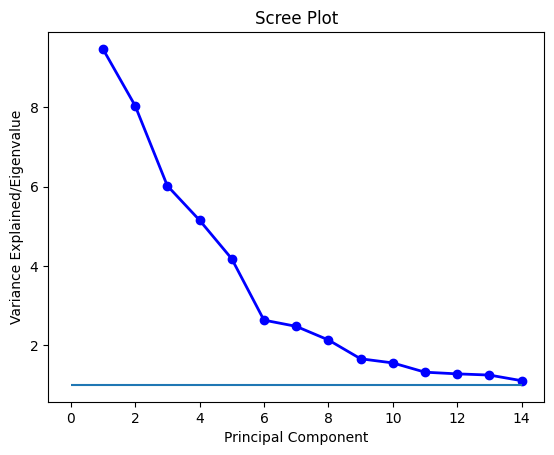

In [32]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(pca.explained_variance_))
plt.show()

In [33]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

pca_df = pd.DataFrame(data=loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(pca_df)

ValueError: Shape of passed values is (67, 14), indices imply (67, 11)

In [34]:
from sklearn.linear_model import LogisticRegression

# logistic regression model
log = LogisticRegression()
log.fit(X_pca,y_train)

LogisticRegression()

In [35]:
score = log.score(X_test_pca, y_test)
print(score)

0.8065


In [36]:
from sklearn.metrics import accuracy_score

# predict using test data
prediction=log.predict(X_test_pca)
# calculate score using accuracy metric
ac_score = accuracy_score(prediction,y_test)
print('The accuracy score:', ac_score)

The accuracy score: 0.8065


In [38]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, prediction)
print(f"Confusion Matrix:\n{conf_matrix}")

Confusion Matrix:
[[1300  109]
 [ 278  313]]


In [39]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, prediction)
print(f"F1 Score: {f1}")

F1 Score: 0.6179664363277394


In [40]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, prediction)
print(f"MCC: {mcc}")

MCC: 0.5057303849058882


In [41]:
logreg_coefs = log.coef_[0]
logreg_coefs

array([-0.46016566, -0.07930922, -0.12456774, -0.15343706,  0.36822   ,
       -0.39095398,  0.09788291, -0.11542698,  0.0687456 ,  0.1224413 ,
       -0.01734764, -0.22772606,  0.10007854, -0.09675986])

In [42]:
odds_ratios = np.exp(logreg_coefs)
odds_ratios

array([0.63117907, 0.92375424, 0.88287845, 0.85775475, 1.44515994,
       0.67641129, 1.10283364, 0.89098563, 1.07116367, 1.13025277,
       0.98280197, 0.79634238, 1.10525773, 0.90777398])

In [43]:
explained_var = pca.explained_variance_ratio_
explained_var

array([0.14128848, 0.11994313, 0.08982995, 0.07687413, 0.0623687 ,
       0.03929428, 0.0369541 , 0.03184046, 0.02475616, 0.0232029 ,
       0.019715  , 0.01908252, 0.01863483, 0.01651476])

In [44]:
importance_df = pd.DataFrame({
    'PC': [f'PC{i + 1}' for i in range(len(logreg_coefs))],
    'LogReg Coefficient': logreg_coefs,
    'Abs Coef': np.abs(logreg_coefs),
    'Odds Ratio': odds_ratios,
    'Explained Variance Ratio': explained_var
})
print(importance_df.sort_values('Abs Coef', ascending=False))


      PC  LogReg Coefficient  Abs Coef  Odds Ratio  Explained Variance Ratio
0    PC1           -0.460166  0.460166    0.631179                  0.141288
5    PC6           -0.390954  0.390954    0.676411                  0.039294
4    PC5            0.368220  0.368220    1.445160                  0.062369
11  PC12           -0.227726  0.227726    0.796342                  0.019083
3    PC4           -0.153437  0.153437    0.857755                  0.076874
2    PC3           -0.124568  0.124568    0.882878                  0.089830
9   PC10            0.122441  0.122441    1.130253                  0.023203
7    PC8           -0.115427  0.115427    0.890986                  0.031840
12  PC13            0.100079  0.100079    1.105258                  0.018635
6    PC7            0.097883  0.097883    1.102834                  0.036954
13  PC14           -0.096760  0.096760    0.907774                  0.016515
1    PC2           -0.079309  0.079309    0.923754                  0.119943

In [45]:
import statsmodels.api as sm

# add a constant to the independent variables
X_train_sm = sm.add_constant(X_pca)

# fit the logistic regression model
log_reg = sm.Logit(y_train, X_train_sm).fit()

# print the summary of the model
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.411052
         Iterations 7
                             Logit Regression Results                            
Dep. Variable:     avg_labeled_utterance   No. Observations:                 8000
Model:                             Logit   Df Residuals:                     7985
Method:                              MLE   Df Model:                           14
Date:                   Thu, 04 Dec 2025   Pseudo R-squ.:                  0.3201
Time:                           03:58:02   Log-Likelihood:                -3288.4
converged:                          True   LL-Null:                       -4836.8
Covariance Type:               nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3205      0.035    -37.326      0.000      -1.390      -1.251
x1   

In [ ]:
pc1_df = pca_df[['PC1']]
pc1_df = pc1_df[(pc1_df['PC1'] <= -0.5) | (pc1_df['PC1'] >= 0.5)]
pc1_df

,PC1
informativeness,0.781593
detail_level,0.562256
explicitness,0.679467
implied_meaning,-0.721151
creative_text,-0.538477
expressfulness,-0.584918
vagueness,-0.585732
matter_of_factness,0.853041
figurativeness,-0.528905
concreteness,0.588272


In [ ]:
pc6_df = pca_df[['PC6']]
pc6_df = pc6_df[(pc6_df['PC6'] <= -0.3) | (pc6_df['PC6'] >= 0.3)]
pc6_df

,PC6
context_dependence,-0.432142
anecdotal_reasoning,-0.336557
creative_text,0.586982
vividness,0.431313
expressfulness,0.352793
figurativeness,0.608615
chronological,-0.304582


In [ ]:
pc5_df = pca_df[['PC5']]
pc5_df = pc5_df[(pc5_df['PC5'] <= -0.3) | (pc5_df['PC5'] >= 0.3)]
pc5_df

,PC5
comprehensibility,-0.411572
persuasiveness,0.412423
logical_reasoning,0.473810
right_wrong,0.505405
supportiveness,-0.301212
empathy,-0.347916
point_faults,-0.409540
tactful,-0.549723
challenge,0.595701
build_connection,-0.315739


In [ ]:
pc4_df = pca_df[['PC4']]
pc4_df = pc4_df[(pc4_df['PC4'] <= -0.4) | (pc4_df['PC4'] >= 0.4)]
pc4_df

,PC4
author_revelation,0.414851
comprehensibility,0.438219
explicitness,0.447518
right_wrong,0.411688
formality,-0.431124
emotionality,0.498595
impersonality,-0.451797
politeness,-0.445525
directness,0.541022
bluntness,0.643614


In [ ]:
pc10_df = pca_df[['PC10']]
pc10_df = pc10_df[(pc10_df['PC10'] <= -0.3) | (pc10_df['PC10'] >= 0.3)]
pc10_df

,PC10
comprehensibility,0.332505
build_connection,-0.320280
conciseness,0.480443
verbosity,-0.352797
context-first,0.314964
setting-first,0.320932


In [ ]:
pc3_df = pca_df[['PC3']]
pc3_df = pc3_df[(pc3_df['PC3'] <= -0.5) | (pc3_df['PC3'] >= 0.5)]
pc3_df

,PC3
vividness,0.602778
narrative,0.751350
narrative_mode,0.750350
storytelling,0.711626
showing,0.611526
chronological,0.523243


In [ ]:
pc7_df = pca_df[['PC7']]
pc7_df = pc7_df[(pc7_df['PC7'] <= -0.3) | (pc7_df['PC7'] >= 0.3)]
pc7_df

,PC7
status_suggestion,0.549442
status_appropriateness,0.457806
personal_choice,-0.360133
shared_responsibility,0.346044
self-reliance,-0.437472
group_wellbeing,0.375699
self_growth,-0.343268
ext_responsibility,0.448243
other_reliance,0.457859


In [47]:
accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8065


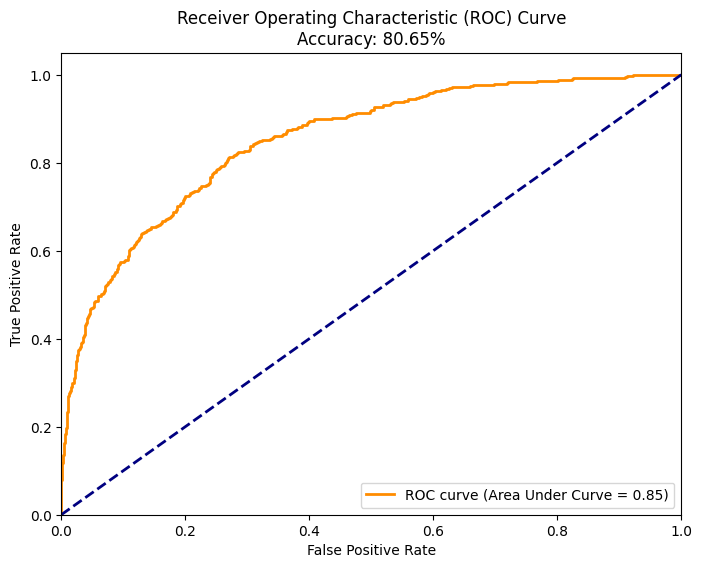

In [48]:
from sklearn.metrics import roc_curve, auc

y_prob = log.predict_proba(X_test_pca)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (Area Under Curve = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve\nAccuracy: {:.2f}%'.format(accuracy * 100))
plt.legend(loc="lower right")
plt.show()

# Older Attempt (Still Usable)

In [ ]:
from sklearn.linear_model import LogisticRegression

# logistic regression model
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [ ]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=11)
X_pca = pca.fit_transform(X_norm)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

[9.41017311 7.99015264 6.04280475 5.14507568 4.21653306 2.63471249
 2.4833375  2.1547617  1.64164222 1.54224544 1.321518  ]
[0.1404363  0.11924408 0.0901821  0.0767845  0.06292704 0.03932013
 0.03706103 0.03215741 0.02449967 0.02301629 0.01972218]


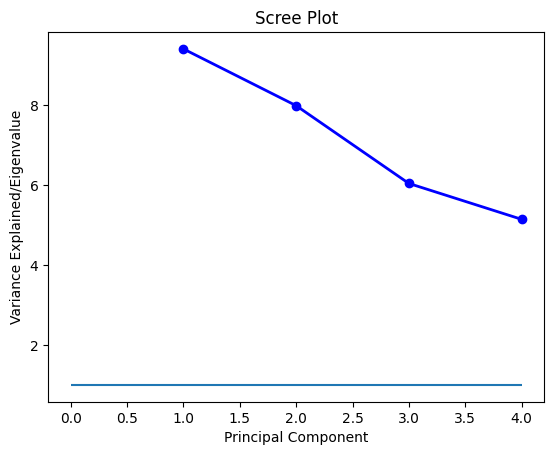

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(pca.explained_variance_))
plt.show()

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

pca_df = pd.DataFrame(data=loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(pca_df)

                            PC1       PC2       PC3       PC4       PC5  \
informativeness        0.794168  0.249275  0.147986 -0.192298  0.110474   
constructive_feedback  0.180097  0.561254 -0.100678  0.112922  0.230784   
author_revelation     -0.270838  0.461586  0.115567  0.417683  0.208713   
comprehensibility      0.341023  0.101369  0.120423  0.457554 -0.402272   
detail_level           0.577467  0.305742  0.422010 -0.247547  0.111463   
...                         ...       ...       ...       ...       ...   
context-first          0.051389  0.286813  0.256366 -0.441543  0.110464   
setting-first          0.119117  0.120613  0.365444 -0.342848 -0.061350   
chronological          0.084458  0.119806  0.517494 -0.283912 -0.168015   
transition_level       0.147128  0.370538  0.414258 -0.334575  0.058786   
causal_level           0.176720  0.402032  0.210978 -0.149941  0.288191   

                            PC6       PC7       PC8       PC9      PC10  \
informativeness        0

In [ ]:
pc1_df = pca_df[['PC1']]
pc1_df = pc1_df[(pc1_df['PC1'] <= -0.5) | (pc1_df['PC1'] >= 0.5)]
pc1_df

,PC1
informativeness,0.794168
detail_level,0.577467
explicitness,0.685244
implied_meaning,-0.718806
creative_text,-0.538791
expressfulness,-0.573532
vagueness,-0.585471
matter_of_factness,0.846649
figurativeness,-0.528258
concreteness,0.584192


In [ ]:
pc2_df = pca_df[['PC2']]
pc2_df = pc2_df[(pc2_df['PC2'] <= -0.5) | (pc2_df['PC2'] >= 0.5)]
pc2_df

,PC2
constructive_feedback,0.561254
persuasiveness,0.590444
logical_reasoning,0.502652
supportiveness,0.682059
empathy,0.606710
group_harmony,0.623128
group_wellbeing,0.524919
critique,0.549402
conflict,0.666725
prosociality,0.741205


In [ ]:
pc3_df = pca_df[['PC3']]
pc3_df = pc3_df[(pc3_df['PC3'] <= -0.5) | (pc3_df['PC3'] >= 0.5)]
pc3_df

,PC3
vividness,0.604966
narrative,0.740431
narrative_mode,0.738929
storytelling,0.700315
showing,0.608182
chronological,0.517494


In [ ]:
pc4_df = pca_df[['PC4']]
pc4_df = pc4_df[(pc4_df['PC4'] <= -0.5) | (pc4_df['PC4'] >= 0.5)]
pc4_df

,PC4
directness,0.541591
bluntness,0.624068


In [ ]:
pc5_df = pca_df[['PC5']]
pc5_df = pc5_df[(pc5_df['PC5'] <= -0.5) | (pc5_df['PC5'] >= 0.5)]
pc5_df

,PC5
right_wrong,0.511502
tactful,-0.562394
challenge,0.601675


In [ ]:
from sklearn.model_selection import train_test_split

# split training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, Y, test_size = 0.3,
    random_state=20, stratify=Y)

In [ ]:
from sklearn.linear_model import LogisticRegression

# logistic regression model
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score

# predict using test data
prediction=log.predict(X_test)
# calculate score using accuracy metric
ac_score = accuracy_score(prediction,y_test)
print('The accuracy score:', ac_score)

The accuracy score: 0.806


In [ ]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, prediction)
print(f"Confusion Matrix:\n{conf_matrix}")

Confusion Matrix:
[[1924  196]
 [ 386  494]]


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, prediction)
print(f"F1 Score: {f1}")

F1 Score: 0.6292993630573248


In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, prediction)
print(f"MCC: {mcc}")

MCC: 0.5073048011461989


# PCA Refinement

In [ ]:
havaldar_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/pca_analysis.xlsx')
havaldar_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,-0.064779,0.771139,0.051573,0.243689,0.199372,0.047147,0.108231,0.167892,-0.123603,0.059569,-0.002453
1,constructive_feedback,0.324787,0.162222,-0.478863,0.323002,0.204519,0.079411,-0.236253,0.069519,0.002559,-0.204018,-0.027459
2,author_revelation,0.092766,-0.402776,-0.084732,0.435797,0.063215,-0.168149,-0.329454,0.093670,-0.083544,0.244981,0.106573
3,comprehensibility,0.081789,0.333251,-0.078432,0.288240,-0.331709,0.331680,-0.345387,-0.141324,0.196284,0.220016,-0.044038
4,detail_level,-0.180852,0.586963,0.315121,0.275626,0.298643,0.030357,-0.033623,0.118838,-0.211163,-0.025068,0.067435
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,0.185874,0.130319,0.274535,0.156484,0.293139,-0.122017,-0.146178,-0.367343,0.258690,-0.047565,0.436136
63,setting-first,0.079052,0.140361,0.400182,0.149439,0.105667,-0.054083,-0.105804,-0.398201,0.218881,-0.087329,0.456701
64,chronological,0.055183,0.091241,0.620071,0.257851,-0.038126,-0.245836,0.016943,-0.157894,0.167268,-0.118034,0.037912
65,transition_level,0.190502,0.182428,0.358683,0.297871,0.363037,-0.151901,-0.039636,-0.098526,0.165955,-0.020465,0.052139


In [ ]:
chinese_havaldar_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/Havaldar/chinese_pca_analysis.xlsx')
chinese_havaldar_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.136112,0.762560,0.210363,0.202981,0.129887,0.137699,-0.081744,0.160401,0.028052,-0.023247,0.057214
1,constructive_feedback,0.295793,0.156802,0.509715,-0.112913,-0.073019,-0.075142,-0.288813,0.145386,-0.140731,-0.242569,0.187419
2,author_revelation,0.097540,-0.491717,0.302433,0.267004,-0.058770,-0.255412,-0.215004,0.041237,0.227368,0.084552,-0.185343
3,comprehensibility,0.115758,0.324950,0.061209,0.047991,-0.468973,0.040278,-0.231112,-0.399808,-0.110301,-0.003887,-0.225756
4,detail_level,0.043579,0.532234,0.143966,0.404293,0.137089,0.146186,-0.207219,0.172334,0.187546,0.074288,0.147357
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,0.319990,0.016964,-0.054097,0.314352,0.324191,-0.217585,0.034260,-0.229155,-0.153131,0.461916,0.050367
63,setting-first,0.167501,0.061709,-0.146163,0.397142,0.214994,-0.087522,0.074871,-0.251668,-0.213253,0.500613,0.023136
64,chronological,0.139509,0.070336,-0.272400,0.630241,0.090203,-0.122285,0.074782,-0.158267,-0.239457,0.145603,-0.111916
65,transition_level,0.325982,0.121142,0.008544,0.502773,0.285096,-0.116861,-0.103293,-0.186342,-0.182376,0.151833,-0.102046


In [ ]:
havaldar_pca.sort_values(by='PC5', key=abs, ascending=False, inplace=True)
havaldar_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
8,logical_reasoning,-0.102171,0.301775,-0.250167,0.333101,0.599618,-0.126580,-0.192773,0.090578,0.086345,0.007405,-0.159356
66,causal_level,0.071363,0.069955,0.034883,0.377090,0.463218,-0.261416,-0.026691,0.051053,0.159780,-0.016917,-0.198758
44,verbosity,0.147408,-0.008917,0.191661,0.157312,0.429179,-0.116391,0.238131,0.135345,-0.382144,0.024816,0.113606
48,directness,-0.541248,0.211756,-0.101893,0.304455,-0.421979,-0.009662,0.073379,-0.008138,0.124780,-0.031308,-0.052058
43,conciseness,-0.096285,0.174403,-0.228447,-0.039323,-0.409490,0.196320,-0.283557,-0.156041,0.467213,0.043326,-0.116404
56,indirect,0.615431,-0.166905,0.024602,-0.224908,0.409108,0.024850,-0.111407,-0.056353,-0.032093,0.031321,0.045832
7,persuasiveness,-0.038257,-0.076320,-0.498809,0.449852,0.398533,0.072010,-0.068945,-0.032001,-0.010096,0.064420,-0.110917
39,abstractness,-0.044867,-0.180653,-0.088116,-0.252846,0.370025,-0.071704,0.159004,0.014136,0.419396,0.381118,-0.308693
65,transition_level,0.190502,0.182428,0.358683,0.297871,0.363037,-0.151901,-0.039636,-0.098526,0.165955,-0.020465,0.052139
51,exposition,-0.161674,0.728729,0.162325,0.189582,0.362434,-0.034259,0.183746,0.168194,-0.047950,0.093918,-0.075303


In [ ]:
chinese_havaldar_pca.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
chinese_havaldar_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
53,narrative_mode,0.018528,-0.089545,-0.404980,0.768432,0.043247,0.011424,0.052981,-0.073969,-0.060052,-0.368528,-0.013230
52,narrative,0.012158,-0.086153,-0.408605,0.766539,0.046631,0.013295,0.054471,-0.071655,-0.061073,-0.369873,-0.016839
55,storytelling,-0.008922,-0.125094,-0.366105,0.673339,0.032259,0.073418,0.027165,-0.071969,-0.053811,-0.462866,0.019649
64,chronological,0.139509,0.070336,-0.272400,0.630241,0.090203,-0.122285,0.074782,-0.158267,-0.239457,0.145603,-0.111916
65,transition_level,0.325982,0.121142,0.008544,0.502773,0.285096,-0.116861,-0.103293,-0.186342,-0.182376,0.151833,-0.102046
9,anecdotal_reasoning,0.037212,-0.263208,-0.282889,0.493526,-0.095032,-0.189938,-0.105116,0.072414,0.360848,-0.021905,0.056022
4,detail_level,0.043579,0.532234,0.143966,0.404293,0.137089,0.146186,-0.207219,0.172334,0.187546,0.074288,0.147357
63,setting-first,0.167501,0.061709,-0.146163,0.397142,0.214994,-0.087522,0.074871,-0.251668,-0.213253,0.500613,0.023136
34,build_connection,0.399602,-0.290217,-0.257148,0.389358,-0.140298,-0.126323,-0.118196,0.011661,0.312999,0.018781,-0.072197
66,causal_level,0.284923,0.076998,0.322453,0.368800,0.341363,-0.191231,-0.057585,-0.081194,-0.156600,0.138350,-0.038529


In [ ]:
subtitles_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/subtitles_pca_analysis.xlsx')
subtitles_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.239836,-0.040844,-0.454100,0.346646,0.313850,0.214640,0.121306,-0.074626,0.029616,0.029642,-0.017462
1,constructive_feedback,-0.000457,0.261348,0.114859,0.151250,0.285520,0.084680,0.285167,-0.118287,-0.073230,-0.272122,0.018425
2,author_revelation,0.251930,0.025562,0.585142,0.148962,-0.084216,-0.171715,0.173523,-0.096811,0.038271,0.428270,-0.036664
3,comprehensibility,0.574500,0.201097,0.044908,0.228455,-0.253461,0.028937,0.074760,0.069699,-0.283377,-0.100852,0.111240
4,detail_level,0.091215,-0.305846,-0.285528,0.476701,0.241441,0.140599,0.159530,-0.141666,0.132925,0.159533,-0.026303
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,-0.339415,-0.199525,-0.182339,0.231769,0.076659,-0.159761,-0.077545,-0.057902,-0.420065,0.036535,-0.139871
63,setting-first,-0.115344,-0.351916,-0.176773,0.351089,-0.034768,0.017599,-0.049695,-0.020465,-0.276701,-0.015397,-0.121365
64,chronological,-0.046318,-0.414062,-0.149715,0.459160,0.064437,-0.222247,0.042310,-0.008554,-0.153565,-0.179743,-0.178604
65,transition_level,-0.108451,-0.322752,-0.148108,0.434976,0.151237,-0.214858,0.050892,-0.145672,-0.215815,-0.093838,-0.315888


In [ ]:
chinese_subtitles_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/UM_Subtitles/chinese_subtitles_pca_analysis.xlsx')
chinese_subtitles_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.234424,-0.211097,-0.394740,0.412801,0.265294,0.262970,0.005664,-0.063919,-0.090588,0.039720,-0.075969
1,constructive_feedback,0.053868,0.278032,-0.075470,-0.023324,0.318216,0.050923,0.284753,0.069175,0.166924,-0.063603,-0.067017
2,author_revelation,0.486722,0.305134,0.385711,0.020624,-0.026087,-0.071035,0.158531,-0.049490,-0.102871,0.400726,0.098517
3,comprehensibility,0.624967,0.061012,-0.128007,0.182386,-0.204382,0.115338,0.110894,-0.011775,0.339335,-0.021318,-0.273675
4,detail_level,0.121483,-0.168990,-0.090957,0.533842,0.241375,0.216585,0.028667,-0.145998,-0.180610,0.145115,0.030584
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,-0.337358,0.007726,-0.019934,0.389503,0.122653,-0.151369,0.029878,-0.101038,0.388949,0.067931,0.495591
63,setting-first,-0.165187,-0.134950,0.002955,0.439162,-0.007394,-0.073505,0.024459,-0.004389,0.290707,-0.083785,0.570724
64,chronological,-0.120245,-0.191818,0.031578,0.594038,0.062653,-0.244926,0.132307,0.043043,0.169524,-0.207906,0.232443
65,transition_level,-0.194391,-0.135358,0.017027,0.511024,0.175875,-0.217629,0.162027,-0.101132,0.234533,-0.158113,0.151062


In [ ]:
subtitles_pca.sort_values(by='PC3', key=abs, ascending=False, inplace=True)
subtitles_pca.head(n=20)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
45,emotionality,0.148146,-0.040817,0.827358,0.160676,-0.108766,-0.070383,-0.103920,-0.156088,0.016084,0.070065,-0.046113
36,expressfulness,-0.029094,-0.250062,0.746227,0.300114,-0.108571,0.281305,-0.108244,-0.079189,0.084734,0.025815,-0.073645
60,engagement,-0.003133,-0.106496,0.643350,0.316752,-0.127440,0.096390,-0.156011,0.022235,-0.084550,-0.156109,-0.015639
38,matter_of_factness,0.515691,-0.047642,-0.634320,0.074015,0.093240,-0.020936,0.091704,0.131816,-0.021747,-0.017765,0.074186
2,author_revelation,0.251930,0.025562,0.585142,0.148962,-0.084216,-0.171715,0.173523,-0.096811,0.038271,0.428270,-0.036664
46,impersonality,-0.223868,-0.092853,-0.551742,-0.109734,0.368429,0.321067,-0.121936,0.085911,-0.063292,-0.149980,0.123853
32,challenge,0.157422,-0.019381,0.527662,-0.140941,0.335336,-0.061786,0.026423,-0.128830,-0.265558,-0.152863,0.195470
54,expository_mode,-0.009011,-0.052215,-0.518150,0.220394,0.458150,0.331621,0.152248,-0.180948,0.031314,0.093035,0.067864
51,exposition,-0.033033,-0.133386,-0.490764,0.284768,0.411538,0.317186,0.133156,-0.178337,0.036008,0.090814,0.069864
35,vividness,-0.088692,-0.498651,0.486743,0.299759,0.009651,0.422666,-0.121837,0.039723,0.169543,-0.058388,-0.073831


In [ ]:
chinese_subtitles_pca.sort_values(by='PC5', key=abs, ascending=False, inplace=True)
chinese_subtitles_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
22,self_responsibility,0.353389,0.179854,0.054564,-0.054721,0.496198,-0.054974,0.471530,0.330300,-0.010565,-0.004851,0.068896
7,persuasiveness,0.300510,0.380873,-0.074679,-0.057476,0.460842,-0.015842,0.007101,-0.100354,0.076353,-0.147205,-0.127615
10,right_wrong,0.320976,0.061234,0.214942,-0.153716,0.441067,-0.224705,-0.092508,-0.031524,0.112068,0.057670,-0.006768
8,logical_reasoning,-0.062709,-0.001292,-0.110716,0.160983,0.425218,0.124158,0.133459,-0.387182,0.188855,0.090135,-0.136153
54,expository_mode,-0.113326,-0.259189,-0.400851,0.358110,0.419870,0.348570,-0.026736,-0.243335,-0.095347,0.107916,-0.092517
32,challenge,0.257842,0.092270,0.313645,-0.218282,0.402789,-0.076169,0.004988,-0.166861,0.229452,-0.067752,-0.072552
51,exposition,-0.123343,-0.247233,-0.344392,0.416320,0.392593,0.340490,-0.030133,-0.234587,-0.112620,0.082520,-0.132224
66,causal_level,-0.047656,0.035714,0.034026,0.201084,0.385631,-0.067208,0.106247,-0.304856,0.228915,0.102386,-0.062461
47,politeness,-0.285876,0.428413,-0.481748,0.294888,-0.379134,0.216555,0.095385,0.019825,0.102011,0.060298,-0.073426
30,tactful,-0.192726,0.509160,-0.452615,0.297897,-0.378284,0.202258,0.131576,0.021049,0.122466,0.080423,-0.063506


In [ ]:
spoken_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/spoken_pca_analysis.xlsx')
spoken_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.730786,0.215299,-0.035998,-0.147632,0.274185,0.023766,-0.213603,0.019489,-0.077543,0.113675,-0.100187
1,constructive_feedback,-0.075214,0.504653,-0.113633,-0.008215,0.022352,0.241839,-0.196644,0.086080,0.025352,-0.128376,0.099597
2,author_revelation,-0.442861,0.294753,0.238216,0.338720,-0.152329,0.107402,0.080471,0.199438,-0.228909,0.272527,-0.185333
3,comprehensibility,0.412083,0.454088,0.402430,0.015960,-0.193048,-0.146251,0.024523,0.259092,-0.097427,-0.149177,-0.039252
4,detail_level,0.482755,0.097420,0.265489,-0.288414,0.296660,0.020671,-0.174509,-0.101993,-0.011881,0.214383,-0.136336
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,-0.260668,-0.263106,-0.081604,-0.406264,0.155674,0.244040,0.175278,0.310615,-0.187500,0.113387,0.262948
63,setting-first,-0.024241,-0.243382,0.154637,-0.397742,0.105158,0.167702,0.178563,0.321382,-0.129773,0.170918,0.447846
64,chronological,-0.044834,-0.194546,0.368987,-0.513058,0.023496,0.274914,0.118945,0.104884,-0.041159,-0.090711,0.258168
65,transition_level,-0.146125,-0.151808,0.183354,-0.477814,0.090378,0.318140,0.057185,0.141146,-0.161265,-0.088953,0.243678


In [ ]:
chinese_spoken_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/UM_Spoken/chinese_spoken_pca_analysis.xlsx')
chinese_spoken_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.733416,0.192669,0.023407,-0.169322,0.331485,0.145927,0.128241,-0.058178,0.069247,0.128868,-0.033465
1,constructive_feedback,-0.105579,0.531671,0.043193,-0.029855,0.175246,-0.128942,0.187198,0.069171,-0.206459,-0.189411,-0.129402
2,author_revelation,-0.468481,0.202307,0.271255,0.338895,-0.115481,-0.120655,0.113721,-0.118896,-0.076330,0.403551,0.051480
3,comprehensibility,0.468135,0.327795,0.443275,0.170040,-0.201298,0.143998,-0.013385,0.032221,-0.256002,-0.098378,0.172298
4,detail_level,0.487690,-0.008527,0.292708,-0.230117,0.381452,0.157135,0.137280,-0.064643,0.125749,0.178321,-0.099895
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,-0.209315,-0.240219,-0.004103,-0.499748,0.107558,-0.279379,0.001911,0.266893,-0.352271,0.057938,-0.078344
63,setting-first,-0.045901,-0.293794,0.137099,-0.428582,0.026533,-0.153433,-0.040806,0.348271,-0.335070,0.011805,-0.189055
64,chronological,0.006279,-0.306327,0.373918,-0.501153,0.046293,-0.235481,0.063723,0.183694,-0.175755,-0.205820,0.031854
65,transition_level,-0.065642,-0.184631,0.263768,-0.525236,0.175931,-0.248486,0.144771,0.086494,-0.252800,-0.166266,0.053761


In [ ]:
spoken_pca.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
spoken_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
49,bluntness,0.410167,0.101871,0.352088,0.527004,0.078075,0.270075,0.179518,-0.146589,-0.110792,-0.090007,0.038886
64,chronological,-0.044834,-0.194546,0.368987,-0.513058,0.023496,0.274914,0.118945,0.104884,-0.041159,-0.090711,0.258168
30,tactful,-0.013515,0.378470,-0.280844,-0.500956,-0.216686,-0.301967,-0.174197,0.236075,0.081717,0.075488,-0.158639
52,narrative,-0.164979,-0.132399,0.682936,-0.494786,0.016496,0.123610,0.118914,-0.094883,0.121975,-0.185063,-0.115229
53,narrative_mode,-0.158677,-0.130774,0.684039,-0.491880,0.014045,0.127505,0.117079,-0.096916,0.126791,-0.188556,-0.119048
55,storytelling,-0.140263,-0.123246,0.662103,-0.481333,0.023422,0.103636,0.105592,-0.100811,0.115244,-0.195585,-0.087041
47,politeness,0.053183,0.360751,-0.298136,-0.480283,-0.110581,-0.330130,-0.193703,0.332279,0.047178,0.038397,-0.088087
65,transition_level,-0.146125,-0.151808,0.183354,-0.477814,0.090378,0.318140,0.057185,0.141146,-0.161265,-0.088953,0.243678
32,challenge,-0.175111,0.282801,0.070794,0.467639,0.305594,0.178307,0.109817,0.159249,-0.063041,-0.085626,0.139692
10,right_wrong,-0.030990,0.334504,0.154700,0.438378,0.238922,0.282115,0.243073,0.124006,0.036188,0.018835,0.129338


In [ ]:
chinese_spoken_pca.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
chinese_spoken_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
49,bluntness,0.297586,0.048407,0.223422,0.535031,0.288810,-0.309687,-0.137619,-0.067674,0.033519,-0.145032,0.012794
65,transition_level,-0.065642,-0.184631,0.263768,-0.525236,0.175931,-0.248486,0.144771,0.086494,-0.252800,-0.166266,0.053761
64,chronological,0.006279,-0.306327,0.373918,-0.501153,0.046293,-0.235481,0.063723,0.183694,-0.175755,-0.205820,0.031854
62,context-first,-0.209315,-0.240219,-0.004103,-0.499748,0.107558,-0.279379,0.001911,0.266893,-0.352271,0.057938,-0.078344
47,politeness,0.071246,0.397630,-0.133641,-0.478947,-0.248050,0.373850,0.120795,0.099900,-0.171210,0.089772,0.120956
30,tactful,-0.018736,0.430497,-0.055853,-0.437200,-0.329391,0.400486,0.128294,0.090433,-0.105586,0.116021,0.174109
63,setting-first,-0.045901,-0.293794,0.137099,-0.428582,0.026533,-0.153433,-0.040806,0.348271,-0.335070,0.011805,-0.189055
53,narrative_mode,-0.115525,-0.351746,0.673758,-0.411531,-0.037688,-0.208985,-0.037946,-0.019485,0.168404,-0.119129,0.021540
52,narrative,-0.119239,-0.353037,0.671951,-0.411313,-0.040930,-0.210193,-0.034226,-0.018202,0.165467,-0.114227,0.022900
55,storytelling,-0.100648,-0.320880,0.637825,-0.393672,-0.035234,-0.196158,-0.041893,-0.005532,0.173569,-0.127692,0.014625


In [ ]:
news_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/news_pca_analysis.xlsx')
news_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.711407,0.100296,-0.307041,0.315571,0.139732,0.162856,0.178526,-0.064835,0.006014,-0.017756,-0.126320
1,constructive_feedback,-0.179394,0.529845,-0.204930,-0.086249,0.114949,0.259862,-0.078803,-0.043896,-0.095601,-0.064413,0.066584
2,author_revelation,-0.598407,0.117177,-0.083558,-0.231168,0.214520,-0.013603,-0.053017,0.048831,0.343336,0.155652,-0.215867
3,comprehensibility,0.318199,0.100969,-0.499996,-0.468995,-0.008404,-0.103804,0.143786,0.360061,-0.113102,-0.103799,0.005116
4,detail_level,0.419114,-0.223676,-0.489900,0.386348,0.060758,0.141038,0.179858,-0.156448,0.029267,0.042931,-0.152457
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,-0.082569,-0.152123,-0.267955,0.506942,-0.054117,0.062793,-0.142475,0.416822,0.073219,0.150092,0.194291
63,setting-first,0.013382,-0.269425,-0.327686,0.386342,-0.079487,0.043217,-0.038869,0.340554,0.039323,0.236859,0.192171
64,chronological,0.014576,-0.368768,-0.455947,0.318923,-0.039933,0.153828,-0.232855,0.182141,-0.145875,0.088171,0.198752
65,transition_level,-0.085346,-0.153729,-0.415946,0.450595,0.019510,0.261146,-0.141075,0.252087,-0.004144,0.008415,0.167281


In [ ]:
chinese_news_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/UM_News/chinese_news_pca_analysis.xlsx')
chinese_news_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.655046,0.255138,0.442985,-0.144504,0.051636,0.209522,0.128979,0.020435,-0.093619,0.105715,-0.090724
1,constructive_feedback,-0.257948,0.512059,0.062725,0.213861,0.125353,0.274932,-0.089835,0.089927,0.057247,-0.129676,-0.031033
2,author_revelation,-0.581917,0.107875,-0.099103,0.239319,0.250111,-0.066856,-0.038379,-0.367538,-0.175557,0.240049,-0.020588
3,comprehensibility,0.283994,0.097117,0.154364,0.589130,-0.057456,0.000106,0.134175,-0.221486,0.181880,-0.204423,-0.245299
4,detail_level,0.352763,-0.055592,0.652584,-0.151259,0.047320,0.202809,0.196898,0.044217,-0.128560,0.153363,-0.029767
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,-0.166438,-0.076298,0.411497,-0.333431,-0.079661,0.002215,-0.182953,-0.383462,0.346434,-0.160058,0.150902
63,setting-first,-0.031842,-0.232875,0.433447,-0.192147,-0.145408,-0.015573,-0.090679,-0.366750,0.345024,-0.209718,0.231464
64,chronological,-0.038163,-0.297987,0.588462,-0.048788,-0.055707,0.116795,-0.261246,0.008074,0.205448,-0.215825,0.085785
65,transition_level,-0.205610,-0.077432,0.572865,-0.219716,0.001852,0.235694,-0.199698,-0.138570,0.089646,-0.185749,0.042233


In [ ]:
news_pca.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
news_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
44,verbosity,-0.200579,0.058320,-0.160699,0.585458,0.094867,0.165281,0.085301,-0.241495,0.139234,0.218041,-0.099615
43,conciseness,0.294144,0.031813,-0.047944,-0.574993,-0.029088,-0.163110,0.015018,0.395685,-0.229629,-0.231424,0.077675
62,context-first,-0.082569,-0.152123,-0.267955,0.506942,-0.054117,0.062793,-0.142475,0.416822,0.073219,0.150092,0.194291
42,formality,0.494857,0.186882,-0.020337,0.506388,-0.003096,-0.118633,0.120069,-0.029703,-0.247456,0.050399,-0.054299
3,comprehensibility,0.318199,0.100969,-0.499996,-0.468995,-0.008404,-0.103804,0.143786,0.360061,-0.113102,-0.103799,0.005116
59,clarity,0.414377,0.030455,-0.563274,-0.468694,0.011506,-0.083457,0.178138,0.263419,-0.037464,-0.094279,-0.003992
51,exposition,0.660379,0.106778,-0.207988,0.467318,0.102508,0.258517,0.211920,-0.083811,0.068022,0.018972,-0.084446
65,transition_level,-0.085346,-0.153729,-0.415946,0.450595,0.019510,0.261146,-0.141075,0.252087,-0.004144,0.008415,0.167281
48,directness,0.649557,-0.015864,-0.310144,-0.449330,0.141603,-0.014623,-0.076884,0.009729,0.007125,-0.049118,0.090820
54,expository_mode,0.705730,0.168900,-0.113345,0.415356,0.095938,0.246361,0.208715,-0.078297,0.058990,0.010005,-0.095756


In [ ]:
chinese_news_pca.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
chinese_news_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
3,comprehensibility,0.283994,0.097117,0.154364,0.589130,-0.057456,0.000106,0.134175,-0.221486,0.181880,-0.204423,-0.245299
59,clarity,0.414275,0.031536,0.262483,0.578018,-0.026396,0.021354,0.219789,-0.149311,0.121691,-0.177842,-0.200666
39,abstractness,-0.485984,0.325342,-0.297975,-0.412761,0.021706,0.166581,-0.033848,-0.023713,0.115044,0.051172,0.047939
46,impersonality,0.649361,0.164235,0.052464,-0.412149,-0.056935,0.027479,0.149541,0.226079,0.250899,-0.072604,-0.021467
43,conciseness,0.349259,-0.077777,-0.320734,0.406775,0.000150,-0.066484,-0.069110,0.010106,0.263849,-0.277460,-0.168627
16,personal_choice,-0.425962,0.314591,0.026314,0.405122,-0.024496,0.364703,-0.119394,0.117903,0.037942,0.157298,0.061318
42,formality,0.468288,0.343712,0.278190,-0.404167,-0.071435,-0.092371,0.113804,0.091847,0.176680,0.106639,-0.160508
48,directness,0.680309,-0.015467,0.058876,0.397332,0.233236,-0.017050,-0.015991,-0.006634,0.070571,-0.086077,0.051044
5,explicitness,0.571543,0.112679,0.378584,0.396204,0.241549,0.022347,0.140724,-0.109455,-0.016755,0.003056,-0.078046
6,context_dependence,-0.251828,-0.064889,-0.276742,-0.387002,0.187740,-0.249939,-0.424196,0.116698,0.035295,-0.045686,-0.082996


In [ ]:
testing_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/testing_pca_analysis.xlsx')
testing_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.561589,0.510285,0.348853,-0.170915,0.169488,-0.053140,0.037659,0.184512,0.114031,0.059441,-0.001890
1,constructive_feedback,-0.205921,0.398649,-0.184688,0.197784,0.270536,-0.263505,0.127988,0.008590,-0.047635,-0.128145,-0.158594
2,author_revelation,-0.538678,0.219347,-0.032734,0.191173,0.260203,0.023660,-0.202044,-0.239620,0.119519,0.336859,0.060972
3,comprehensibility,0.136551,0.251630,0.226553,0.614834,-0.035280,0.057448,-0.347556,0.035693,-0.265950,-0.108902,0.099957
4,detail_level,0.232774,0.381354,0.639175,-0.233510,0.075799,-0.038393,0.096632,0.139071,0.180473,0.083968,-0.047535
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,-0.136553,0.168016,0.376617,-0.389098,0.004704,-0.166884,-0.286548,-0.187972,-0.315575,0.034976,-0.229202
63,setting-first,-0.025791,0.140974,0.442081,-0.238540,-0.060376,-0.152341,-0.238304,-0.139431,-0.321268,0.040196,-0.241063
64,chronological,-0.069037,0.103145,0.566519,-0.152998,-0.004125,-0.254174,-0.014836,-0.265480,-0.215258,-0.059739,-0.098394
65,transition_level,-0.139080,0.277636,0.494221,-0.290707,0.174961,-0.304264,-0.112754,-0.209471,-0.130147,-0.055903,-0.042499


In [ ]:
chinese_testing_pca = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/UM_Testing/chinese_testing_pca_analysis.xlsx')
chinese_testing_pca

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.466440,0.575554,0.401795,-0.177713,-0.120255,-0.042652,0.178428,-0.041895,-0.099179,0.127758,0.007045
1,constructive_feedback,-0.273384,0.384253,-0.102437,0.128100,-0.204067,-0.316622,0.020360,0.179091,0.032789,-0.096599,0.283184
2,author_revelation,-0.600136,0.059577,-0.062120,0.283357,-0.242466,-0.016644,-0.221516,-0.186652,0.017349,0.246759,-0.111250
3,comprehensibility,0.126315,0.018831,0.151401,0.594177,0.061787,-0.113684,-0.038309,-0.294950,0.199895,-0.357669,0.053452
4,detail_level,0.135818,0.386581,0.653577,-0.197776,-0.047874,0.012835,0.165167,-0.001830,-0.158671,0.161504,0.082854
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,-0.163517,0.204697,0.353727,-0.337529,0.015509,-0.231989,-0.341573,-0.163491,0.303000,-0.137214,-0.027914
63,setting-first,-0.025433,0.125510,0.417823,-0.220473,0.049136,-0.203806,-0.284232,-0.225076,0.333829,-0.164731,-0.028359
64,chronological,-0.129655,0.074230,0.618155,-0.118789,0.075052,-0.092344,-0.236715,0.149064,0.143248,-0.182382,-0.145151
65,transition_level,-0.224778,0.237400,0.568352,-0.189002,-0.096762,-0.231565,-0.222965,0.103067,0.129440,-0.181668,-0.157835


In [ ]:
testing_pca.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
testing_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
59,clarity,0.251907,0.314541,0.355530,0.618772,-0.056709,0.096565,-0.234021,0.113200,-0.179903,-0.070119,0.058863
3,comprehensibility,0.136551,0.251630,0.226553,0.614834,-0.035280,0.057448,-0.347556,0.035693,-0.265950,-0.108902,0.099957
48,directness,0.654036,0.037677,-0.010758,0.512610,0.033878,0.127919,0.023338,-0.032567,-0.056243,-0.076682,0.010906
43,conciseness,0.240932,-0.302106,-0.313108,0.508674,-0.070159,0.092122,-0.217002,0.150429,-0.325441,-0.236118,0.079566
42,formality,0.420465,0.308666,0.160231,-0.493239,-0.176041,0.175123,0.168552,0.146290,-0.074981,-0.015682,-0.093823
56,indirect,-0.654922,-0.009621,-0.115321,-0.474496,0.029258,-0.068170,-0.118647,0.025165,-0.086425,0.092364,-0.001661
39,abstractness,-0.374691,-0.005083,-0.501052,-0.472553,0.099886,0.053682,0.065585,0.104756,-0.099453,-0.082732,0.094804
44,verbosity,-0.199946,0.386509,0.375325,-0.432887,0.065235,-0.004222,0.214129,-0.107749,0.235652,0.212424,-0.016442
6,context_dependence,-0.183558,-0.379228,-0.346005,-0.431261,-0.021507,0.035969,0.079069,-0.297675,-0.001458,-0.038688,-0.021563
5,explicitness,0.442304,0.465978,0.364951,0.428935,0.113464,0.093742,-0.100256,0.036764,0.004533,0.054627,0.001170


In [ ]:
chinese_testing_pca.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
chinese_testing_pca.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
59,clarity,0.279860,0.100948,0.347439,0.598363,0.090341,-0.061034,0.073600,-0.255638,0.130521,-0.205019,0.043298
3,comprehensibility,0.126315,0.018831,0.151401,0.594177,0.061787,-0.113684,-0.038309,-0.294950,0.199895,-0.357669,0.053452
48,directness,0.683981,-0.028298,0.041247,0.451350,-0.069301,0.094224,-0.053759,0.065195,-0.042175,-0.087950,-0.104252
5,explicitness,0.386227,0.381775,0.428681,0.438126,-0.163418,0.053971,0.021628,-0.174087,-0.058048,0.028408,0.103463
39,abstractness,-0.381140,0.139275,-0.491997,-0.430586,-0.133597,0.032853,0.093088,0.029571,0.028134,-0.097658,-0.157356
42,formality,0.458397,0.479960,0.000081,-0.418089,0.166073,0.171727,0.124481,0.088589,0.014675,0.097069,0.096628
56,indirect,-0.647465,0.032325,-0.126454,-0.414654,0.030102,-0.114950,-0.027503,-0.122469,0.143335,0.068030,0.195956
16,personal_choice,-0.420473,0.261597,-0.065390,0.407135,-0.085797,-0.181970,-0.006291,0.226687,0.211933,0.104011,0.038906
6,context_dependence,-0.128015,-0.254755,-0.378877,-0.401890,-0.003745,0.205667,-0.308088,0.304327,-0.037181,0.047243,0.013495
22,self_responsibility,-0.343844,0.369997,-0.105266,0.391705,-0.233583,-0.128946,0.118367,0.419121,0.247184,0.068964,0.036823


In [ ]:
pca_df = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/joint_pca_analysis.xlsx')
pca_df

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.812573,0.175628,0.124564,-0.214450,0.123054,0.097456,-0.121959,0.061892,-0.042704,-0.070977,-0.040434
1,constructive_feedback,0.217737,0.550465,-0.102610,0.089180,0.237668,-0.151214,-0.213449,-0.035262,-0.129630,0.164989,-0.226518
2,author_revelation,-0.208703,0.502256,0.158118,0.367020,0.240773,-0.275296,-0.090879,-0.222328,0.119993,-0.214412,0.017434
3,comprehensibility,0.359558,0.178115,0.157254,0.441958,-0.390074,0.090346,-0.115482,-0.150710,0.160579,0.311644,0.057446
4,detail_level,0.617651,0.228511,0.400227,-0.304042,0.122951,0.044641,-0.112993,0.012210,-0.059314,-0.155891,-0.084614
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,0.055174,0.210191,0.224708,-0.479964,0.127459,-0.241866,0.072359,-0.159186,0.225993,0.242438,0.237711
63,setting-first,0.134409,0.091405,0.358209,-0.377699,-0.045305,-0.130981,0.069665,-0.101106,0.235712,0.193864,0.331947
64,chronological,0.091797,0.093820,0.496717,-0.323452,-0.143456,-0.277077,0.141389,0.110419,0.047915,0.212697,0.181145
65,transition_level,0.185979,0.333396,0.379026,-0.381160,0.113599,-0.293794,-0.010050,-0.014310,0.012271,0.201725,0.118985


In [ ]:
chinese_pca_df = pd.read_excel('/content/drive/MyDrive/High and Low Context Files/Results/chinese_joint_pca_analysis.xlsx')
chinese_pca_df

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,informativeness,0.783584,0.311507,0.141155,-0.145037,0.101721,0.163910,0.039845,0.056360,-0.008087,-0.123596,-0.042901
1,constructive_feedback,0.136832,0.572180,-0.106710,0.138450,0.219325,0.017233,0.234360,-0.097769,-0.082853,-0.028624,0.344395
2,author_revelation,-0.331639,0.424222,0.082605,0.451841,0.157377,-0.106814,0.168531,-0.285915,0.172492,-0.076790,-0.188467
3,comprehensibility,0.309334,0.037178,0.096171,0.424181,-0.442544,0.183578,0.018494,-0.109542,-0.050725,0.334102,0.070819
4,detail_level,0.559283,0.366765,0.409923,-0.177756,0.110986,0.146147,0.038630,0.005129,0.010272,-0.194091,-0.053325
...,...,...,...,...,...,...,...,...,...,...,...,...
62,context-first,0.059622,0.348563,0.266729,-0.406405,0.124955,-0.226850,0.103736,-0.183344,0.086846,0.450069,-0.152978
63,setting-first,0.108231,0.142444,0.361730,-0.340559,-0.043171,-0.154098,0.050662,-0.129436,0.073302,0.506816,-0.195260
64,chronological,0.084194,0.140286,0.533423,-0.284030,-0.162105,-0.288869,0.126480,0.091695,-0.075680,0.306589,-0.035748
65,transition_level,0.121827,0.393363,0.433177,-0.312477,0.037210,-0.197567,0.200815,0.003509,-0.130254,0.277548,-0.059054


In [ ]:
pca_df.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
pca_df.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
49,bluntness,0.187810,-0.135973,0.274074,0.642753,0.373960,-0.040650,0.212076,0.091319,-0.072636,0.081975,0.048687
48,directness,0.558709,-0.178438,0.133360,0.558887,-0.177206,0.014644,0.075783,0.082394,-0.019126,0.079197,0.133331
62,context-first,0.055174,0.210191,0.224708,-0.479964,0.127459,-0.241866,0.072359,-0.159186,0.225993,0.242438,0.237711
56,indirect,-0.571100,0.244558,-0.203616,-0.463354,0.189610,-0.034143,-0.060875,-0.118623,0.109191,0.082212,-0.200517
45,emotionality,-0.548686,0.345302,0.306855,0.458382,0.076509,0.088343,0.017738,-0.112621,-0.034658,-0.081192,0.070652
43,conciseness,0.004527,-0.293604,-0.155050,0.457629,-0.338437,0.106014,-0.044911,-0.085686,0.129924,0.478837,0.082531
3,comprehensibility,0.359558,0.178115,0.157254,0.441958,-0.390074,0.090346,-0.115482,-0.150710,0.160579,0.311644,0.057446
59,clarity,0.514776,0.156183,0.263713,0.428877,-0.368248,0.150526,-0.148878,-0.120475,0.107388,0.203940,0.026105
42,formality,0.589337,0.026250,-0.076509,-0.420723,0.047495,0.320002,0.071128,0.151431,0.109892,0.050727,-0.036002
47,politeness,0.237471,0.372446,-0.300051,-0.416122,-0.440889,0.064062,-0.249941,-0.168914,0.132038,0.062472,-0.039903


In [ ]:
chinese_pca_df.sort_values(by='PC4', key=abs, ascending=False, inplace=True)
chinese_pca_df.head(n=10)

,Unnamed: 0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
49,bluntness,0.169978,-0.187687,0.205614,0.624322,0.392110,-0.149904,-0.078568,0.128376,-0.094259,0.073791,0.011378
48,directness,0.526314,-0.295529,0.091673,0.512625,-0.172232,-0.037901,-0.040389,0.083874,-0.070933,0.137504,-0.019023
5,explicitness,0.645536,0.179795,0.218039,0.493803,-0.126755,0.102693,-0.034991,-0.081553,0.000286,0.031581,-0.004902
45,emotionality,-0.627413,0.211748,0.256689,0.493534,0.034842,0.076591,-0.099726,-0.108140,-0.075639,0.021299,-0.126761
46,impersonality,0.586778,-0.133526,-0.121677,-0.457522,0.148068,0.169887,-0.186110,0.262609,-0.056766,0.049745,0.138668
2,author_revelation,-0.331639,0.424222,0.082605,0.451841,0.157377,-0.106814,0.168531,-0.285915,0.172492,-0.076790,-0.188467
47,politeness,0.181524,0.435968,-0.255005,-0.439754,-0.428934,0.191033,0.069843,-0.172940,0.109757,0.038545,0.066534
10,right_wrong,0.022095,0.358918,0.062573,0.432001,0.489260,-0.125503,-0.099142,0.024938,0.025923,0.041433,0.211671
59,clarity,0.463947,0.063539,0.204050,0.431624,-0.418540,0.231615,-0.014908,-0.092101,-0.025600,0.253065,0.049382
3,comprehensibility,0.309334,0.037178,0.096171,0.424181,-0.442544,0.183578,0.018494,-0.109542,-0.050725,0.334102,0.070819
